In [2]:
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor

print(" Librerías cargadas correctamente. ")


 Librerías cargadas correctamente. 


In [4]:
import sys
!{sys.executable} -m pip install pandas numpy openpyxl



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [5]:
ruta_base = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw"

inventario = pd.read_excel(os.path.join(ruta_base, "inventario.xlsx"))
ventas = pd.read_excel(os.path.join(ruta_base, "Ventas.xlsx"))
compras = pd.read_excel(os.path.join(ruta_base, "Compras.xlsx"))

print("Archivos cargados correctamente.")


Archivos cargados correctamente.


In [6]:
def resumen_df(nombre, df):
    print(f"\n TABLA: {nombre}")
    print(f"   Filas: {df.shape[0]}")
    print(f"   Columnas: {df.shape[1]}")
    print("   Lista de columnas:")
    for col in df.columns:
        print("    -", col)

resumen_df("INVENTARIO", inventario)
resumen_df("VENTAS", ventas)
resumen_df("COMPRAS", compras)



 TABLA: INVENTARIO
   Filas: 82314
   Columnas: 20
   Lista de columnas:
    - proveedor
    - Marca
    - sku
    - Código
    - producto
    - costo
    - precio de venta
    - tipo
    - Departamento
    - Categoria
    - Sub Categoria
    - Especifico
    - Familia
    - inventario final
    - Valor Costo INVENTARIO
    - fecha
    - Sistema
    - PROVEEDOR_CORRECTO
    - MARCA_CORRECTA
    - CATAGORIA_LOTTUS

 TABLA: VENTAS
   Filas: 47429
   Columnas: 38
   Lista de columnas:
    - SISTEMA
    - Origen
    - ALMACEN
    - Ubicación
    - Referencia Proveedor
    - Ref.Gerais
    - Código de Barras
    - Codigo Wis
    -  Descripicón
    - Cantidad
    - Precio de Venta Unitario
    - Total Factura$
    - Costo Unitario
    - Costo Total facturado$
    - Precio Unitario (USD)
    -  Seriales
    - Fecha
    - MES
    - AÑO
    - Mov
    - Nº de Factura
    - CLIENTE
    - Vendedor
    - Proveedor
    - MARCA
    - DEPARTAMENTO
    - Categoría del producto
    - Sub Categoría
    

In [7]:
columnas = {
    "inventario": inventario.columns.tolist(),
    "ventas": ventas.columns.tolist(),
    "compras": compras.columns.tolist()
}

columnas


{'inventario': ['proveedor',
  'Marca',
  'sku',
  'Código',
  'producto',
  'costo',
  'precio de venta',
  'tipo',
  'Departamento',
  'Categoria',
  'Sub Categoria',
  'Especifico',
  'Familia',
  'inventario final',
  'Valor Costo INVENTARIO',
  'fecha',
  'Sistema',
  'PROVEEDOR_CORRECTO',
  'MARCA_CORRECTA',
  'CATAGORIA_LOTTUS'],
 'ventas': ['SISTEMA',
  'Origen',
  'ALMACEN',
  'Ubicación',
  'Referencia Proveedor',
  'Ref.Gerais',
  'Código de Barras',
  'Codigo Wis',
  ' Descripicón',
  'Cantidad',
  'Precio de Venta Unitario',
  'Total Factura$',
  'Costo Unitario',
  'Costo Total facturado$',
  'Precio Unitario (USD)',
  ' Seriales',
  'Fecha',
  'MES',
  'AÑO',
  'Mov',
  'Nº de Factura',
  'CLIENTE',
  'Vendedor',
  'Proveedor',
  'MARCA',
  'DEPARTAMENTO',
  'Categoría del producto',
  'Sub Categoría',
  'Categoría Específica',
  'Familia',
  'MOVIMIENTO',
  'PROVEEDOR_CORRECTO',
  'MARCA_CORRECTA',
  'PRODUCTO SERIADO',
  'TIPO',
  'REPORTADO',
  'FECHA DE ACTIVACION',


In [8]:
total_filas = (
    inventario.shape[0] +
    ventas.shape[0] +
    compras.shape[0]
)

print(" Total de filas combinadas:", total_filas)

columnas_unicas = set(
    inventario.columns.tolist() +
    ventas.columns.tolist() +
    compras.columns.tolist()
)

print(" Total de variables únicas:", len(columnas_unicas))

 Total de filas combinadas: 147988
 Total de variables únicas: 78


In [10]:
import sys
!{sys.executable} -m pip install yfinance


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [13]:
import yfinance as yf
import pandas as pd
import os

print("Iniciando scraping del precio del oro...")

# Ruta donde guardarás el archivo
ruta_raw = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw"

# 1. Descargar precio del oro desde Yahoo Finance (nuevo ticker)
oro = yf.download("GC=F", start="2010-01-01")

# 2. Eliminar MultiIndex si existe
oro.columns = [col[0] if isinstance(col, tuple) else col for col in oro.columns]

# 3. Calcular precio por gramo
oro["precio_gramo_usd"] = oro["Close"] / 31.1035

# 4. Limpiar columnas
oro = oro.reset_index()
oro = oro.rename(columns={
    "Date": "fecha",
    "Close": "precio_onza_usd"
})

# 5. Guardar en Excel
ruta_excel = os.path.join(ruta_raw, "precio_oro.xlsx")
oro.to_excel(ruta_excel, index=False)

print("Scraping del oro completado.")
print("Archivo guardado en:", ruta_excel)
print("Filas descargadas:", oro.shape[0])


Iniciando scraping del precio del oro...


[*********************100%***********************]  1 of 1 completed


Scraping del oro completado.
Archivo guardado en: /Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/precio_oro.xlsx
Filas descargadas: 4099


In [14]:
import sys
!{sys.executable} -m pip install pytrends


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [16]:
from pytrends.request import TrendReq
import pandas as pd
import os

print("Iniciando scraping de estacionalidad del lujo...")

# Ruta donde guardarás el archivo
ruta_raw = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw"

# Inicializar conexión
pytrends = TrendReq(hl='es-ES', tz=0)

# Keywords que sí funcionan
keywords = [
    "relojes de lujo",
    "joyas de lujo",
    "alta relojería",
    "alta joyería",
    "luxury goods"
]

# Construir payload
pytrends.build_payload(
    kw_list=keywords,
    timeframe="2010-01-01 2026-01-01",
    geo=""   # global
)

# Descargar estacionalidad
df = pytrends.interest_over_time()

# Limpiar
if "isPartial" in df.columns:
    df = df.drop(columns=["isPartial"])

df = df.reset_index()

# Guardar en Excel
ruta_excel = os.path.join(ruta_raw, "estacionalidad_lujo.xlsx")
df.to_excel(ruta_excel, index=False)

print(" Scraping de estacionalidad completado.")
print(" Archivo guardado en:", ruta_excel)
print(" Filas descargadas:", df.shape[0])


Iniciando scraping de estacionalidad del lujo...
 Scraping de estacionalidad completado.
 Archivo guardado en: /Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/estacionalidad_lujo.xlsx
 Filas descargadas: 193


In [17]:
import kagglehub

In [18]:
import sys
!{sys.executable} -m pip install kagglehub


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [19]:
import os
import pandas as pd
import kagglehub

# 1. Credenciales de Kaggle
os.environ['KAGGLE_USERNAME'] = "mariagabrielafiguera"
os.environ['KAGGLE_KEY'] = "c56ad26224693a9a987dac77af25d1f2"

print("Credenciales de Kaggle listas.")

# 2. Descargar dataset desde Kaggle
path = kagglehub.dataset_download("rkiattisak/luxury-watches-price-dataset")
print("Path to dataset files:", path)

# 3. Ruta donde SIEMPRE guardamos scraping
ruta_raw = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw"

# 4. Buscar el CSV dentro de la carpeta descargada
csv_file = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_file = os.path.join(path, file)
        break

if csv_file is None:
    raise FileNotFoundError("No se encontró ningún archivo CSV en la descarga de KaggleHub.")

print("CSV encontrado:", csv_file)

# 5. Cargar CSV
df = pd.read_csv(csv_file)

# 6. Guardar como Excel en tu carpeta RAW
excel_path = os.path.join(ruta_raw, "benchmark_relojes.xlsx")
df.to_excel(excel_path, index=False)

print("✔ Benchmark guardado como Excel en:", excel_path)
print("✔ Filas:", df.shape[0])
print("✔ Columnas:", df.shape[1])


Credenciales de Kaggle listas.
Path to dataset files: /Users/mariafiguera/.cache/kagglehub/datasets/rkiattisak/luxury-watches-price-dataset/versions/1
CSV encontrado: /Users/mariafiguera/.cache/kagglehub/datasets/rkiattisak/luxury-watches-price-dataset/versions/1/Luxury watch.csv
✔ Benchmark guardado como Excel en: /Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/benchmark_relojes.xlsx
✔ Filas: 507
✔ Columnas: 14


In [20]:
import sys

# Instalar SQLAlchemy (si ya está instalado, no pasa nada)
!{sys.executable} -m pip install sqlalchemy


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [57]:
from sqlalchemy import create_engine, text

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

with engine.connect() as conn:
    result = conn.execute(text("SELECT 1 AS test;"))
    print("Resultado SELECT 1:", list(result))

Resultado SELECT 1: [(1,)]


In [64]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS catalogo_auditoria;"))

sql_create = """
CREATE TABLE catalogo_auditoria AS
WITH inv AS (
    SELECT
        UPPER(TRIM(PROVEEDOR_CORRECTO)) AS proveedor,
        UPPER(TRIM(MARCA_CORRECTA)) AS marca,
        UPPER(TRIM(CATAGORIA_LOTTUS)) AS categoria_lottus,
        UPPER(TRIM(Departamento)) AS departamento,
        sku,
        Familia AS familia,
        Especifico AS material,
        "precio de venta" AS precio_inventario
    FROM inventario
),
comp AS (
    SELECT
        UPPER(TRIM(PROVEEDOR_CORRECTO)) AS proveedor,
        UPPER(TRIM(MARCA_CORRECTA)) AS marca,
        UPPER(TRIM(CATAGORIA_LOTTUS)) AS categoria_lottus,
        SKU AS sku,
        "precio costo (nacionalizado)" AS costo_nacionalizado
    FROM compras
),
ven AS (
    SELECT
        UPPER(TRIM(PROVEEDOR_CORRECTO)) AS proveedor,
        UPPER(TRIM(MARCA_CORRECTA)) AS marca,
        UPPER(TRIM(CATAGORIA_LOTTUS)) AS categoria_lottus,
        "Referencia Proveedor" AS sku,
        "Precio de Venta Unitario" AS precio_venta_facturada
    FROM ventas
)
SELECT
    inv.departamento,
    inv.categoria_lottus,
    inv.proveedor,
    inv.marca,
    inv.sku,
    inv.familia,
    inv.material,

    CAST(
        REPLACE(REPLACE(COALESCE(comp.costo_nacionalizado, '0'), ',', ''), ' ', '')
        AS REAL
    ) AS costo_nacionalizado,

    CAST(
        REPLACE(REPLACE(COALESCE(ven.precio_venta_facturada, inv.precio_inventario, '0'), ',', ''), ' ', '')
        AS REAL
    ) AS precio_venta

FROM inv
LEFT JOIN comp
    ON inv.sku = comp.sku
    AND inv.marca = comp.marca

LEFT JOIN ven
    ON inv.sku = ven.sku
    AND inv.marca = ven.marca;
"""

with engine.connect() as conn:
    conn.execute(text(sql_create))

In [67]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS catalogo_auditoria;"))


In [70]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS catalogo_auditoria;"))

sql_create = """
CREATE TABLE catalogo_auditoria AS
WITH ven AS (
    SELECT
        UPPER(TRIM(PROVEEDOR_CORRECTO)) AS proveedor,
        UPPER(TRIM(MARCA_CORRECTA)) AS marca,
        UPPER(TRIM(CATAGORIA_LOTTUS)) AS categoria_lottus,
        UPPER(TRIM(DEPARTAMENTO)) AS departamento,
        "Referencia Proveedor" AS sku,
        Familia AS familia,
        "Precio de Venta Unitario" AS precio_venta
    FROM ventas
),
comp AS (
    SELECT
        UPPER(TRIM(PROVEEDOR_CORRECTO)) AS proveedor,
        UPPER(TRIM(MARCA_CORRECTA)) AS marca,
        UPPER(TRIM(CATAGORIA_LOTTUS)) AS categoria_lottus,
        SKU AS sku,
        "precio costo (nacionalizado)" AS costo_nacionalizado
    FROM compras
),
inv AS (
    SELECT
        UPPER(TRIM(PROVEEDOR_CORRECTO)) AS proveedor,
        UPPER(TRIM(MARCA_CORRECTA)) AS marca,
        UPPER(TRIM(CATAGORIA_LOTTUS)) AS categoria_lottus,
        sku,
        Especifico AS material
    FROM inventario
)
SELECT
    ven.departamento,
    ven.categoria_lottus,
    ven.proveedor,
    ven.marca,
    ven.sku,
    ven.familia,
    inv.material,

    CAST(
        REPLACE(REPLACE(COALESCE(comp.costo_nacionalizado, '0'), ',', ''), ' ', '')
        AS REAL
    ) AS costo_nacionalizado,

    CAST(
        REPLACE(REPLACE(COALESCE(ven.precio_venta, '0'), ',', ''), ' ', '')
        AS REAL
    ) AS precio_venta

FROM ven
LEFT JOIN comp
    ON ven.sku = comp.sku
    AND ven.marca = comp.marca

LEFT JOIN inv
    ON ven.sku = inv.sku
    AND ven.marca = inv.marca;
"""

with engine.connect() as conn:
    conn.execute(text(sql_create))


In [71]:
pd.read_sql("SELECT * FROM catalogo_auditoria LIMIT 20;", engine)


,departamento,categoria_lottus,proveedor,marca,sku,familia,material,costo_nacionalizado,precio_venta
0,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,450.0
1,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,450.0
2,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,450.0
3,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,450.0
4,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,NaN,None,NaN,0.0,2244.0
5,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,NaN,None,NaN,0.0,2244.0
6,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DRD8454S01MH-WG,None,NaN,0.0,780.0
7,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,465.0
8,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,465.0
9,JOYERIA,JOYERIA,ACE JEWERLY LTD.,GERAIS,DR77751R01W,None,ORO BLANCO,0.0,465.0


In [65]:
import pandas as pd
from sqlalchemy import create_engine, text

# Ruta oficial de la base SQL
db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Ruta oficial de los archivos internos/externos
ventas_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/Ventas.xlsx"

# Cargar archivo Excel
df_ventas = pd.read_excel(ventas_path)

# Guardar en SQL
df_ventas.to_sql("ventas", engine, if_exists="replace", index=False)

# Validar
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM ventas;"))
    print("Filas cargadas en ventas:", list(result))

Filas cargadas en ventas: [(47429,)]


In [24]:
import pandas as pd
from sqlalchemy import create_engine, text

# Ruta oficial de la base SQL
db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Ruta oficial del archivo COMPRAS
compras_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/Compras.xlsx"

# Cargar archivo Excel
df_compras = pd.read_excel(compras_path)

# Guardar en SQL
df_compras.to_sql("compras", engine, if_exists="replace", index=False)

# Validar
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM compras;"))
    print("Filas cargadas en compras:", list(result))

Filas cargadas en compras: [(18245,)]


In [25]:
import pandas as pd
from sqlalchemy import create_engine, text

# Ruta oficial de la base SQL
db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Ruta oficial del archivo INVENTARIO
inventario_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/inventario.xlsx"

# Cargar archivo Excel
df_inventario = pd.read_excel(inventario_path)

# Guardar en SQL
df_inventario.to_sql("inventario", engine, if_exists="replace", index=False)

# Validar
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM inventario;"))
    print("Filas cargadas en inventario:", list(result))

Filas cargadas en inventario: [(82314,)]


In [26]:
import pandas as pd
from sqlalchemy import create_engine, text

# Ruta oficial de la base SQL
db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Ruta oficial del archivo PRECIO ORO
oro_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/precio_oro.xlsx"

# Cargar archivo Excel
df_oro = pd.read_excel(oro_path)

# Guardar en SQL
df_oro.to_sql("precio_oro", engine, if_exists="replace", index=False)

# Validar
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM precio_oro;"))
    print("Filas cargadas en precio_oro:", list(result))


Filas cargadas en precio_oro: [(4099,)]


In [27]:
import pandas as pd
from sqlalchemy import create_engine, text

# Ruta oficial de la base SQL
db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Ruta oficial del archivo ESTACIONALIDAD LUJO
estacionalidad_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/estacionalidad_lujo.xlsx"

# Cargar archivo Excel
df_estacionalidad = pd.read_excel(estacionalidad_path)

# Guardar en SQL
df_estacionalidad.to_sql("estacionalidad_lujo", engine, if_exists="replace", index=False)

# Validar
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM estacionalidad_lujo;"))
    print("Filas cargadas en estacionalidad_lujo:", list(result))

Filas cargadas en estacionalidad_lujo: [(193,)]


In [28]:
import pandas as pd
from sqlalchemy import create_engine, text

# Ruta oficial de la base SQL
db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Ruta oficial del archivo BENCHMARK RELOJES
benchmark_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/benchmark_relojes.xlsx"

# Cargar archivo Excel
df_benchmark = pd.read_excel(benchmark_path)

# Guardar en SQL
df_benchmark.to_sql("benchmark_relojes", engine, if_exists="replace", index=False)

# Validar
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM benchmark_relojes;"))
    print("Filas cargadas en benchmark_relojes:", list(result))


Filas cargadas en benchmark_relojes: [(507,)]


In [30]:
from sqlalchemy import create_engine, text

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

with engine.connect() as conn:
    result = conn.execute(text("PRAGMA table_info(ventas);"))
    print(list(result))

[(0, 'SISTEMA', 'TEXT', 0, None, 0), (1, 'Origen', 'TEXT', 0, None, 0), (2, 'ALMACEN', 'TEXT', 0, None, 0), (3, 'Ubicación', 'TEXT', 0, None, 0), (4, 'Referencia Proveedor', 'TEXT', 0, None, 0), (5, 'Ref.Gerais', 'TEXT', 0, None, 0), (6, 'Código de Barras', 'TEXT', 0, None, 0), (7, 'Codigo Wis', 'FLOAT', 0, None, 0), (8, ' Descripicón', 'TEXT', 0, None, 0), (9, 'Cantidad', 'BIGINT', 0, None, 0), (10, 'Precio de Venta Unitario', 'FLOAT', 0, None, 0), (11, 'Total Factura$', 'FLOAT', 0, None, 0), (12, 'Costo Unitario', 'FLOAT', 0, None, 0), (13, 'Costo Total facturado$', 'FLOAT', 0, None, 0), (14, 'Precio Unitario (USD)', 'FLOAT', 0, None, 0), (15, ' Seriales', 'TEXT', 0, None, 0), (16, 'Fecha', 'DATETIME', 0, None, 0), (17, 'MES', 'TEXT', 0, None, 0), (18, 'AÑO', 'BIGINT', 0, None, 0), (19, 'Mov', 'TEXT', 0, None, 0), (20, 'Nº de Factura', 'TEXT', 0, None, 0), (21, 'CLIENTE', 'TEXT', 0, None, 0), (22, 'Vendedor', 'TEXT', 0, None, 0), (23, 'Proveedor', 'TEXT', 0, None, 0), (24, 'MARCA', '

In [31]:
from sqlalchemy import create_engine, text

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

sql = """
CREATE TABLE IF NOT EXISTS precio_promedio_marca AS
SELECT 
    MARCA AS marca,
    AVG("Precio de Venta Unitario") AS precio_promedio_marca
FROM ventas
WHERE DEPARTAMENTO = 'RELOJERIA'
GROUP BY MARCA;
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_promedio_marca LIMIT 10;"))
    print(list(result))


[(None, 12500.0), (' Audemars Piguet', 60466.416666666664), (' BAUME MERCIER ', 500.0), (' Bell & Ross', 5139.771875), (' Bell Ross', 5023.766666666666), (' Bomberg', 571.0), (' Breitling', 3636.6666666666665), (' Bvlgari', 9300.0), (' CARTIER ', 8816.864890038809), (' Cartier', 12083.333333333334)]


In [32]:
from sqlalchemy import create_engine, text

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

sql = """
CREATE TABLE IF NOT EXISTS precio_promedio_marca_limpia AS
SELECT
    TRIM(UPPER(MARCA)) AS marca,
    AVG("Precio de Venta Unitario") AS precio_promedio_marca
FROM ventas
WHERE DEPARTAMENTO = 'RELOJERIA'
GROUP BY TRIM(UPPER(MARCA));
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_promedio_marca_limpia LIMIT 10;"))
    print(list(result))


[(None, 12500.0), ('AUDEMARS PIGUET', 58787.3125), ('BAUME MERCIER', 500.0), ('BELL & ROSS', 5215.626687116564), ('BELL ROSS', 5023.766666666666), ('BLANCPAIN X SWATCH', 491.0829657245903), ('BOMBERG', 571.0), ('BREITLING', 6190.298378378378), ('BVLGARI', 9300.0), ('CARTIER', 9237.481084577115)]


In [34]:
from sqlalchemy import create_engine, text

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

sql = """
CREATE TABLE IF NOT EXISTS precio_promedio_marca_limpia AS
SELECT
    REPLACE(
        REPLACE(
            REPLACE(
                TRIM(UPPER(MARCA)),
            '&', ' '),
        '  ', ' '),
    '  ', ' ') AS marca_normalizada,
    AVG("Precio de Venta Unitario") AS precio_promedio_marca
FROM ventas
WHERE DEPARTAMENTO = 'RELOJERIA'
GROUP BY
    REPLACE(
        REPLACE(
            REPLACE(
                TRIM(UPPER(MARCA)),
            '&', ' '),
        '  ', ' '),
    '  ', ' ');
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_promedio_marca_limpia LIMIT 20;"))
    print(list(result))


[(None, 12500.0), ('AUDEMARS PIGUET', 58787.3125), ('BAUME MERCIER', 500.0), ('BELL & ROSS', 5215.626687116564), ('BELL ROSS', 5023.766666666666), ('BLANCPAIN X SWATCH', 491.0829657245903), ('BOMBERG', 571.0), ('BREITLING', 6190.298378378378), ('BVLGARI', 9300.0), ('CARTIER', 9237.481084577115), ('CASIO', 549.2), ('COVER', 440.90368713923374), ('CUERVO Y SOBRINOS', 3980.0), ('DE GRISOGONO', 16560.0), ('DIOR', 1058.0), ('FLIK FLAK', 50.205916637955895), ('FRANCK MULLER', 12968.731707317073), ('FREDERIQUE CONSTANT', 2077.099956030707), ('GIRARD PERREGAUX', 23307.782608695652), ('GRAHAM', 2433.25)]


In [36]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS precio_promedio_marca_limpia;"))

In [37]:
sql = """
CREATE TABLE precio_promedio_marca_limpia AS
SELECT
    REPLACE(
        REPLACE(
            REPLACE(
                TRIM(UPPER(MARCA)),
            '&', ' '),
        '  ', ' '),
    '  ', ' ') AS marca_normalizada,
    AVG("Precio de Venta Unitario") AS precio_promedio_marca
FROM ventas
WHERE DEPARTAMENTO = 'RELOJERIA'
GROUP BY
    REPLACE(
        REPLACE(
            REPLACE(
                TRIM(UPPER(MARCA)),
            '&', ' '),
        '  ', ' '),
    '  ', ' ');
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_promedio_marca_limpia LIMIT 20;"))
    print(list(result))


[(None, 12500.0), ('AUDEMARS PIGUET', 58787.3125), ('BAUME MERCIER', 500.0), ('BELL ROSS', 5185.8038860103625), ('BLANCPAIN X SWATCH', 491.0829657245903), ('BOMBERG', 571.0), ('BREITLING', 6190.298378378378), ('BVLGARI', 9300.0), ('CARTIER', 9237.481084577115), ('CASIO', 549.2), ('COVER', 440.90368713923374), ('CUERVO Y SOBRINOS', 3980.0), ('DE GRISOGONO', 16560.0), ('DIOR', 1058.0), ('FLIK FLAK', 50.205916637955895), ('FRANCK MULLER', 12968.731707317073), ('FREDERIQUE CONSTANT', 2077.099956030707), ('GIRARD PERREGAUX', 23307.782608695652), ('GRAHAM', 2433.25), ('HAMILTON', 574.25)]


In [38]:
with engine.connect() as conn:
    result = conn.execute(text("PRAGMA table_info(benchmark_relojes);"))
    print(list(result))


[(0, 'Brand', 'TEXT', 0, None, 0), (1, 'Model', 'TEXT', 0, None, 0), (2, 'Case Material', 'TEXT', 0, None, 0), (3, 'Strap Material', 'TEXT', 0, None, 0), (4, 'Movement Type', 'TEXT', 0, None, 0), (5, 'Water Resistance', 'TEXT', 0, None, 0), (6, 'Case Diameter (mm)', 'FLOAT', 0, None, 0), (7, 'Case Thickness (mm)', 'FLOAT', 0, None, 0), (8, 'Band Width (mm)', 'FLOAT', 0, None, 0), (9, 'Dial Color', 'TEXT', 0, None, 0), (10, 'Crystal Material', 'TEXT', 0, None, 0), (11, 'Complications', 'TEXT', 0, None, 0), (12, 'Power Reserve', 'TEXT', 0, None, 0), (13, 'Price (USD)', 'TEXT', 0, None, 0)]


In [42]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS precio_promedio_benchmark_marca;"))

In [43]:
sql_create = """
CREATE TABLE precio_promedio_benchmark_marca AS
SELECT
    UPPER(TRIM(Brand)) AS marca_benchmark,
    AVG(CAST("Price (USD)" AS FLOAT)) AS precio_benchmark_marca
FROM benchmark_relojes
GROUP BY UPPER(TRIM(Brand));
"""

with engine.connect() as conn:
    conn.execute(text(sql_create))

In [45]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS benchmark_marca_limpia;"))


In [46]:
sql = """
CREATE TABLE benchmark_marca_limpia AS
SELECT
    -- Normalización global de marca
    REPLACE(
        REPLACE(
            REPLACE(
                REPLACE(
                    UPPER(TRIM(Brand)),
                'Ö', 'O'),
            '&', ' '),
        '  ', ' '),
    '  ', ' ') AS marca_benchmark_limpia,

    CAST("Price (USD)" AS FLOAT) AS precio_usd
FROM benchmark_relojes;
"""

with engine.connect() as conn:
    conn.execute(text(sql))


In [47]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS precio_promedio_benchmark_marca;"))

In [48]:
sql = """
CREATE TABLE precio_promedio_benchmark_marca AS
SELECT
    marca_benchmark_limpia,
    AVG(precio_usd) AS precio_benchmark_marca
FROM benchmark_marca_limpia
GROUP BY marca_benchmark_limpia;
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_promedio_benchmark_marca LIMIT 20;"))
    print(list(result))


[('A. LANGE SOHNE', 23.0), ('A. LANGE SöHNE', 20.0), ('AUDEMARS PIGUET', 23.44736842105263), ('BAUME MERCIER', 2.0), ('BELL ROSS', 3.0), ('BLANCPAIN', 12.758620689655173), ('BREGUET', 20.5), ('BREITLING', 4.125), ('BULGARI', 10.666666666666666), ('BULOVA', 650.0), ('CARTIER', 6.2631578947368425), ('CHOPARD', 5.571428571428571), ('CITIZEN', 498.0), ('FREDERIQUE CONSTANT', 1.0), ('GIRARD-PERREGAUX', 9.15), ('GLASHüTTE ORIGINAL', 9.0), ('HAMILTON', 409.0), ('HUBLOT', 13.076923076923077), ('IWC', 6.487179487179487), ('JAEGER-LECOULTRE', 6.3125)]


In [49]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS benchmark_marca_limpia;"))


In [50]:
sql = """
CREATE TABLE benchmark_marca_limpia AS
SELECT
    -- Normalización completa
    REPLACE(
        REPLACE(
            REPLACE(
                REPLACE(
                    REPLACE(
                        REPLACE(
                            UPPER(TRIM(Brand)),
                        'Ö', 'O'),
                    'Ü', 'U'),
                '&', ' '),
            '-', ' '),
        '  ', ' '),
    '  ', ' ') AS marca_benchmark_limpia,

    CAST("Price (USD)" AS FLOAT) AS precio_usd
FROM benchmark_relojes;
"""

with engine.connect() as conn:
    conn.execute(text(sql))


In [51]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS precio_promedio_benchmark_marca;"))

In [52]:
sql = """
CREATE TABLE precio_promedio_benchmark_marca AS
SELECT
    marca_benchmark_limpia,
    AVG(precio_usd) AS precio_benchmark_marca
FROM benchmark_marca_limpia
GROUP BY marca_benchmark_limpia;
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_promedio_benchmark_marca LIMIT 30;"))
    print(list(result))


[('A. LANGE SOHNE', 23.0), ('A. LANGE SöHNE', 20.0), ('AUDEMARS PIGUET', 23.44736842105263), ('BAUME MERCIER', 2.0), ('BELL ROSS', 3.0), ('BLANCPAIN', 12.758620689655173), ('BREGUET', 20.5), ('BREITLING', 4.125), ('BULGARI', 10.666666666666666), ('BULOVA', 650.0), ('CARTIER', 6.2631578947368425), ('CHOPARD', 5.571428571428571), ('CITIZEN', 498.0), ('FREDERIQUE CONSTANT', 1.0), ('GIRARD PERREGAUX', 9.15), ('GLASHüTTE ORIGINAL', 9.0), ('HAMILTON', 409.0), ('HUBLOT', 13.076923076923077), ('IWC', 6.487179487179487), ('JAEGER LECOULTRE', 6.3125), ('JAQUET DROZ', 8.4), ('LONGINES', 1.2), ('MONTBLANC', 3.6666666666666665), ('OMEGA', 4.826086956521739), ('ORIS', 1.0), ('PANERAI', 6.88), ('PATEK PHILIPPE', 38.03030303030303), ('PIAGET', 16.0), ('RADO', 1.0), ('ROLEX', 10.518518518518519)]


In [53]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS precio_ideal_relojeria;"))


In [54]:
sql = """
CREATE TABLE precio_ideal_relojeria AS
SELECT
    v."Referencia Proveedor" AS sku,
    v.MARCA AS marca_original,
    p.marca_normalizada AS marca_limpia,
    v."Precio de Venta Unitario" AS precio_real,

    -- Precio internacional por marca
    b.precio_benchmark_marca,

    -- Precio promedio de tu tienda por marca
    p.precio_promedio_marca,

    -- Precio ideal final
    CASE
        WHEN b.precio_benchmark_marca IS NOT NULL THEN b.precio_benchmark_marca
        ELSE p.precio_promedio_marca
    END AS precio_ideal

FROM ventas v
LEFT JOIN precio_promedio_marca_limpia p
    ON p.marca_normalizada = TRIM(UPPER(v.MARCA))

LEFT JOIN precio_promedio_benchmark_marca b
    ON b.marca_benchmark_limpia = p.marca_normalizada

WHERE v.DEPARTAMENTO = 'RELOJERIA';
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_ideal_relojeria LIMIT 20;"))
    print(list(result))


[('511.OS.8900.LR.CZD15-1', ' Hublot', 'HUBLOT', 36400.0, 13.076923076923077, 17305.8395026643, 13.076923076923077), ('SGEF56P1', ' Seiko', 'SEIKO', 65.0, 130.8, 65.0, 130.8), ('25940SK.OO.D002CA.03', ' Audemars Piguet', 'AUDEMARS PIGUET', 23000.0, 23.44736842105263, 58787.3125, 23.44736842105263), ('26356PT.OO.D028CR.01', ' Audemars Piguet', 'AUDEMARS PIGUET', 60000.0, 23.44736842105263, 58787.3125, 23.44736842105263), ('26010OR.00.D088CR.01', ' Audemars Piguet', 'AUDEMARS PIGUET', 123097.0, 23.44736842105263, 58787.3125, 23.44736842105263), ('5267/200A-011', ' Patek Phillipe', 'PATEK PHILLIPE', 68000.0, None, 97833.33333333333, 97833.33333333333), ('5990-1A011-1', ' Patek Philippe', 'PATEK PHILIPPE', 171000.0, 38.03030303030303, 132500.0, 38.03030303030303), ('5980R-001', ' Patek Philippe', 'PATEK PHILIPPE', 155000.0, 38.03030303030303, 132500.0, 38.03030303030303), ('5267/200A-011', ' Patek Philippe', 'PATEK PHILIPPE', 65000.0, 38.03030303030303, 132500.0, 38.03030303030303), ('5968

In [55]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS ventas_marca_limpia;"))


In [56]:
sql = """
CREATE TABLE ventas_marca_limpia AS
SELECT
    *,
    REPLACE(
        REPLACE(
            REPLACE(
                REPLACE(
                    UPPER(TRIM(MARCA)),
                'Ö', 'O'),
            '&', ' '),
        '  ', ' '),
    '  ', ' ') AS marca_limpia
FROM ventas;
"""

with engine.connect() as conn:
    conn.execute(text(sql))


In [57]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS precio_ideal_relojeria;"))

In [58]:
sql = """
CREATE TABLE precio_ideal_relojeria AS
SELECT
    v."Referencia Proveedor" AS sku,
    v.MARCA AS marca_original,
    v.marca_limpia AS marca_limpia,
    v."Precio de Venta Unitario" AS precio_real,

    b.precio_benchmark_marca,
    p.precio_promedio_marca,

    CASE
        WHEN b.precio_benchmark_marca IS NOT NULL THEN b.precio_benchmark_marca
        ELSE p.precio_promedio_marca
    END AS precio_ideal

FROM ventas_marca_limpia v

LEFT JOIN precio_promedio_marca_limpia p
    ON p.marca_normalizada = v.marca_limpia

LEFT JOIN precio_promedio_benchmark_marca b
    ON b.marca_benchmark_limpia = v.marca_limpia

WHERE v.DEPARTAMENTO = 'RELOJERIA';
"""

with engine.connect() as conn:
    conn.execute(text(sql))
    result = conn.execute(text("SELECT * FROM precio_ideal_relojeria LIMIT 20;"))
    print(list(result))


[('511.OS.8900.LR.CZD15-1', ' Hublot', 'HUBLOT', 36400.0, 13.076923076923077, 17305.8395026643, 13.076923076923077), ('SGEF56P1', ' Seiko', 'SEIKO', 65.0, 130.8, 65.0, 130.8), ('25940SK.OO.D002CA.03', ' Audemars Piguet', 'AUDEMARS PIGUET', 23000.0, 23.44736842105263, 58787.3125, 23.44736842105263), ('26356PT.OO.D028CR.01', ' Audemars Piguet', 'AUDEMARS PIGUET', 60000.0, 23.44736842105263, 58787.3125, 23.44736842105263), ('26010OR.00.D088CR.01', ' Audemars Piguet', 'AUDEMARS PIGUET', 123097.0, 23.44736842105263, 58787.3125, 23.44736842105263), ('5267/200A-011', ' Patek Phillipe', 'PATEK PHILLIPE', 68000.0, None, 97833.33333333333, 97833.33333333333), ('5990-1A011-1', ' Patek Philippe', 'PATEK PHILIPPE', 171000.0, 38.03030303030303, 132500.0, 38.03030303030303), ('5980R-001', ' Patek Philippe', 'PATEK PHILIPPE', 155000.0, 38.03030303030303, 132500.0, 38.03030303030303), ('5267/200A-011', ' Patek Philippe', 'PATEK PHILIPPE', 65000.0, 38.03030303030303, 132500.0, 38.03030303030303), ('5968

In [70]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS compras_mensuales;"))


In [71]:
sql = """
CREATE TABLE compras_mensuales AS
SELECT
    SKU AS sku,
    strftime('%Y-%m', "Fecha RECEPCION") AS mes,
    SUM(Cantidad) AS compras_mes
FROM compras
GROUP BY sku, mes;
"""
with engine.connect() as conn:
    conn.execute(text(sql))


In [72]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS ventas_mensuales;"))


In [73]:
sql = """
CREATE TABLE ventas_mensuales AS
SELECT
    "Referencia Proveedor" AS sku,
    strftime('%Y-%m', Fecha) AS mes,
    SUM(Cantidad) AS ventas_mes
FROM ventas
GROUP BY sku, mes;
"""
with engine.connect() as conn:
    conn.execute(text(sql))


In [74]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS inventario_inicial;"))


In [75]:
sql = """
CREATE TABLE inventario_inicial AS
SELECT
    sku,
    MAX(fecha) AS fecha_cierre,
    FIRST_VALUE("inventario final") OVER (
        PARTITION BY sku
        ORDER BY fecha DESC
    ) AS inventario_inicial
FROM inventario
WHERE strftime('%Y-%m', fecha) = '2025-06'
GROUP BY sku;
"""
with engine.connect() as conn:
    conn.execute(text(sql))


In [76]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS inventario_mensual;"))


In [77]:
sql = """
CREATE TABLE inventario_mensual AS
WITH meses AS (
    SELECT '2025-06' AS mes UNION ALL
    SELECT '2025-07' UNION ALL
    SELECT '2025-08' UNION ALL
    SELECT '2025-09' UNION ALL
    SELECT '2025-10' UNION ALL
    SELECT '2025-11' UNION ALL
    SELECT '2025-12' UNION ALL
    SELECT '2026-01' UNION ALL
    SELECT '2026-02' UNION ALL
    SELECT '2026-03'
),
base AS (
    SELECT DISTINCT sku FROM inventario
)
SELECT
    b.sku,
    m.mes,
    COALESCE(i.inventario_inicial, 0) AS inventario_inicial,
    COALESCE(c.compras_mes, 0) AS compras_mes,
    COALESCE(v.ventas_mes, 0) AS ventas_mes,
    COALESCE(i.inventario_inicial, 0)
        + COALESCE(c.compras_mes, 0)
        - COALESCE(v.ventas_mes, 0) AS inventario_final
FROM base b
CROSS JOIN meses m
LEFT JOIN inventario_inicial i
    ON i.sku = b.sku AND m.mes = '2025-06'
LEFT JOIN compras_mensuales c
    ON c.sku = b.sku AND c.mes = m.mes
LEFT JOIN ventas_mensuales v
    ON v.sku = b.sku AND v.mes = m.mes;
"""
with engine.connect() as conn:
    conn.execute(text(sql))


In [78]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT 
            mes,
            SUM(inventario_final) AS inventario_total_cierre
        FROM inventario_mensual
        GROUP BY mes
        ORDER BY mes;
    """))
    print(list(result))


[('2025-06', 10183), ('2025-07', -575), ('2025-08', 276), ('2025-09', -234), ('2025-10', 539), ('2025-11', 86), ('2025-12', -920), ('2026-01', 60), ('2026-02', 194), ('2026-03', -249)]


In [79]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT DISTINCT c.SKU
        FROM compras c
        LEFT JOIN inventario i ON c.SKU = i.sku
        WHERE i.sku IS NULL;
    """))
    print(list(result))


[('5968R-001',), ('JPLA1700',), ('JPLA1701',), ('JPLB1034',), ('JPLB1035',), ('JPLR0689',), ('JPLR0690',), ('JPLR0691',), ('JDIA1877',), ('JZRA3115',), ('133159',), ('133160',), ('198340',), ('073300',), ('DNG6021R04M18R-15',), ('DNG6021R04M18Y-2',), ('DNG6021R04M18Y-3',), ('DNH1654R06M18Y-4',), ('DML5719R01WM18Y',), ('DNH1660R04M18R-1',), ('DNH1662R03M18W-7',), ('DNH3547R02M18Y-2',), ('DNH3550R02M18R-1',), ('JDIA1974',), ('JCAA1947',), ('JCAA1950',), ('JANB2487',), ('JDIA1968',), ('JDIA1969',), ('JDIA1970',), ('JDIA1971',), ('JDIA1972',), ('JCAA1948',), ('JCAA1949',), ('JCAA1951',), ('JDIA1978',), ('JDIA1979',), ('JDIA1980',), ('JDIA1981',), ('JDIA1982',), ('JDIA1984',), ('JDIA1985',), ('JDIA1975',), ('JANA1365',), ('JANA1366',), ('JDIA1976',), ('JDIA1977',), ('JANB2489',), ('PAC4010O700000000',), ('PAC4012O7WHRDB000',), ('PBC0100O700000000 M',), ('PCC4012O7WHRDB000',), ('PCC4030O7WHRDB0MP-1',), ('POC4012O7WHRDB000',), ('107110',), ('115205',), ('214195',), ('506790',), ('1160355',), 

In [80]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT DISTINCT v."Referencia Proveedor"
        FROM ventas v
        LEFT JOIN inventario i ON v."Referencia Proveedor" = i.sku
        WHERE i.sku IS NULL;
    """))
    print(list(result))


[(None,), ('DRD8454S01MH-WG',), ('DR12515W',), ('L1135395',), ('DN10916W',), ('DRD6285R01M',), ('G-13757',), ('AFGBABR50',), ('J370400',), ('J590310',), ('B160508',), ('J370310',), ('J600300',), ('J360200',), ('J700100',), ('J370045',), ('B160140',), ('02-102-1232-2/58',), ('R2480RWN',), ('P24326RWN',), ('R24700EWN',), ('P2804RAM(P)',), ('P3075RAMWN',), ('P1463/1DWN',), ('R24677RWN',), ('P1469-1DWN-1',), ('SGEF56P1',), ('882664006341',), ('9781614286806',), ('9781614284734',), ('9781614280583',), ('9781614282938',), ('9781614286349',), ('9781614287209',), ('9781649802408',), ('25940SK.OO.D002CA.03',), ('26356PT.OO.D028CR.01',), ('26010OR.00.D088CR.01',), ('SR10418',), ('RM11-02-RG',), ('5267/200A-011',), ('5990-1A011-1',), ('5980R-001',), ('5968R-001',), ('EN969OA',), ('EN874OR1',), ('B-P-046',), ('B-V-064',), ('BRS-EA-ST-LGD/SCR',), ('BR0392-HERITAGE-CE',), ('BR0392-BL-CE',), ('BR0394-SW-CE/SRB',), ('BR0392-D-BL-CE/SRB',), ('BR0392-BLC-ST',), ('BR0392-PHANTOM-CE',), ('BRV292-MKA-ST/SF

In [81]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT mes, SUM(inventario_inicial), SUM(compras_mes), SUM(ventas_mes)
        FROM inventario_mensual
        GROUP BY mes
        ORDER BY mes;
    """))
    print(list(result))


[('2025-06', 11278, 54, 1149), ('2025-07', 0, 177, 752), ('2025-08', 0, 913, 637), ('2025-09', 0, 331, 565), ('2025-10', 0, 1058, 519), ('2025-11', 0, 543, 457), ('2025-12', 0, 158, 1078), ('2026-01', 0, 255, 195), ('2026-02', 0, 466, 272), ('2026-03', 0, 122, 371)]


In [82]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS inventario_mensual_final;"))


In [83]:
sql = """
WITH RECURSIVE inv AS (
    -- Mes inicial (junio 2025)
    SELECT
        sku,
        mes,
        inventario_inicial,
        compras_mes,
        ventas_mes,
        inventario_inicial + compras_mes - ventas_mes AS inventario_final
    FROM inventario_mensual
    WHERE mes = '2025-06'

    UNION ALL

    -- Meses siguientes
    SELECT
        m.sku,
        m.mes,
        i.inventario_final AS inventario_inicial,
        m.compras_mes,
        m.ventas_mes,
        i.inventario_final + m.compras_mes - m.ventas_mes AS inventario_final
    FROM inventario_mensual m
    JOIN inv i
        ON m.sku = i.sku
       AND m.mes = (
            SELECT mes
            FROM inventario_mensual
            WHERE mes > i.mes
            ORDER BY mes
            LIMIT 1
       )
)
SELECT * FROM inv;
"""

with engine.connect() as conn:
    conn.execute(text(sql))


In [86]:
sql = """
CREATE TABLE inventario_mensual_final AS
WITH RECURSIVE inv AS (
    -- Mes inicial
    SELECT
        sku,
        mes,
        inventario_inicial,
        compras_mes,
        ventas_mes,
        inventario_inicial + compras_mes - ventas_mes AS inventario_final
    FROM inventario_mensual
    WHERE mes = '2025-06'

    UNION ALL

    -- Meses siguientes encadenados
    SELECT
        m.sku,
        m.mes,
        i.inventario_final AS inventario_inicial,
        m.compras_mes,
        m.ventas_mes,
        i.inventario_final + m.compras_mes - m.ventas_mes AS inventario_final
    FROM inventario_mensual m
    JOIN inv i
        ON m.sku = i.sku
       AND m.mes = (
            SELECT mes
            FROM inventario_mensual
            WHERE mes > i.mes
            ORDER BY mes
            LIMIT 1
       )
)
SELECT * FROM inv;
"""

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS inventario_mensual_final;"))
    conn.execute(text(sql))


In [87]:
with engine.connect() as conn:
    result = conn.execute(text("""
        SELECT 
            mes,
            SUM(inventario_final) AS inventario_final_total
        FROM inventario_mensual_final
        GROUP BY mes
        ORDER BY mes;
    """))

inventarios_finales = pd.DataFrame(result.fetchall(), columns=["mes", "inventario_final_total"])
inventarios_finales


,mes,inventario_final_total
0,2025-06,10183
1,2025-07,9603
2,2025-08,9878
3,2025-09,9644
4,2025-10,10171
5,2025-11,10254
6,2025-12,9327
7,2026-01,9399
8,2026-02,9592
9,2026-03,9342


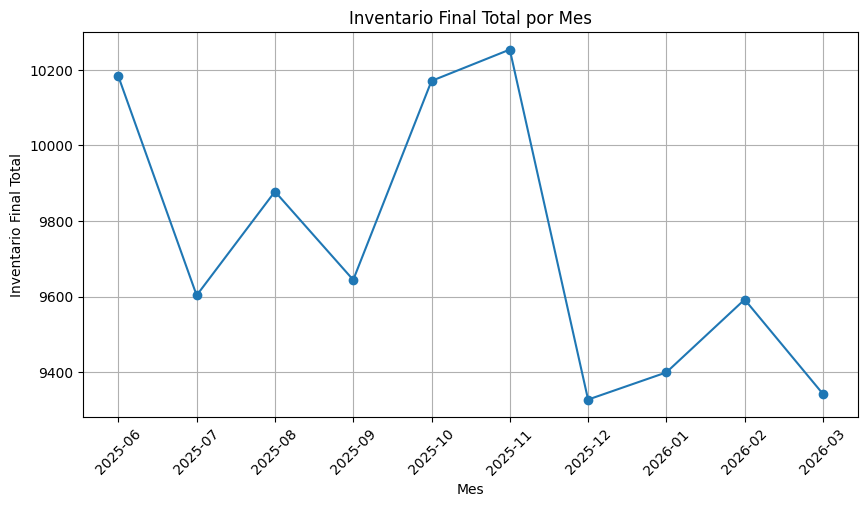

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(inventarios_finales["mes"], inventarios_finales["inventario_final_total"], marker="o")
plt.title("Inventario Final Total por Mes")
plt.xlabel("Mes")
plt.ylabel("Inventario Final Total")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [90]:
import os

# Ruta oficial del proyecto (la que NO debe cambiar)
ruta_raw = "/Users/mariafiguera/Downloads/ProyectoDataScience/data/raw"

# Nombre del archivo
nombre_archivo = "inventario_final_mensual.xlsx"

# Ruta completa
ruta_excel = os.path.join(ruta_raw, nombre_archivo)

# Guardar el archivo en la ruta correcta
inventarios_finales.to_excel(ruta_excel, index=False)

print("Archivo guardado en:", ruta_excel)


Archivo guardado en: /Users/mariafiguera/Downloads/ProyectoDataScience/data/raw/inventario_final_mensual.xlsx


In [91]:
import pandas as pd

# --- COMPRAS: solo columnas numéricas relevantes ---
cols_compras = [
    "Cantidad",
    "precio costo (nacionalizado)",
    "total precio costo (nacionalizado)",
    "costo Ex Works",
    "total costo Ex Works",
    "Lead Time Días",
    "Margen de Nacionalización",
    "Factor de Importación"
]

query_compras = f"""
SELECT {", ".join([f'"{c}"' for c in cols_compras])}
FROM compras
"""

dfc = pd.read_sql(query_compras, engine)

# --- VENTAS: solo columnas numéricas relevantes ---
cols_ventas = [
    "Cantidad",
    "Precio de Venta Unitario",
    "Total Factura$",
    "Costo Unitario",
    "Costo Total facturado$",
    "Precio Unitario (USD)"
]

query_ventas = f"""
SELECT {", ".join([f'"{c}"' for c in cols_ventas])}
FROM ventas
"""

dfv = pd.read_sql(query_ventas, engine)

print(dfc.shape, dfv.shape)


(18245, 8) (47429, 6)


In [92]:
# --- COMPRAS ---
desc_compras = dfc.describe().T
desc_compras["skew"] = dfc.skew(numeric_only=True)
desc_compras["kurtosis"] = dfc.kurtosis(numeric_only=True)

# --- VENTAS ---
desc_ventas = dfv.describe().T
desc_ventas["skew"] = dfv.skew(numeric_only=True)
desc_ventas["kurtosis"] = dfv.kurtosis(numeric_only=True)

desc_compras, desc_ventas


(                                      count          mean           std  \
 Cantidad                            18245.0      2.603015      6.400468   
 precio costo (nacionalizado)        18245.0   2336.186864  10515.101482   
 total precio costo (nacionalizado)  18243.0   2577.710107  11384.446260   
 costo Ex Works                      18244.0   1965.523054   9523.059255   
 total costo Ex Works                18245.0   2211.548104  10344.393754   
 Lead Time Días                      18245.0  10803.405207  19455.266894   
 Margen de Nacionalización           18235.0      0.132561      0.789524   
 Factor de Importación               18239.0      1.947028     45.401768   
 
                                               min         25%         50%  \
 Cantidad                               -40.000000    1.000000    1.000000   
 precio costo (nacionalizado)        -29925.000000  172.440000  419.890000   
 total precio costo (nacionalizado) -277200.000000  292.000000  688.000000   
 c

In [93]:
modas_compras = dfc.mode().iloc[0]
modas_ventas = dfv.mode().iloc[0]

modas_compras, modas_ventas

(Cantidad                                1.00
 precio costo (nacionalizado)          210.23
 total precio costo (nacionalizado)    360.00
 costo Ex Works                        142.78
 total costo Ex Works                  142.78
 Lead Time Días                         18.00
 Margen de Nacionalización               0.00
 Factor de Importación                   1.05
 Name: 0, dtype: float64,
 Cantidad                      1.0
 Precio de Venta Unitario    325.0
 Total Factura$              325.0
 Costo Unitario              172.0
 Costo Total facturado$      172.0
 Precio Unitario (USD)       360.0
 Name: 0, dtype: float64)

In [94]:
# --- COMPRAS ---
Q1_c = dfc.quantile(0.25)
Q3_c = dfc.quantile(0.75)
IQR_c = Q3_c - Q1_c

outliers_compras = ((dfc < (Q1_c - 1.5 * IQR_c)) | (dfc > (Q3_c + 1.5 * IQR_c))).sum()

# --- VENTAS ---
Q1_v = dfv.quantile(0.25)
Q3_v = dfv.quantile(0.75)
IQR_v = Q3_v - Q1_v

outliers_ventas = ((dfv < (Q1_v - 1.5 * IQR_v)) | (dfv > (Q3_v + 1.5 * IQR_v))).sum()

outliers_compras, outliers_ventas


(Cantidad                              3668
 precio costo (nacionalizado)          2731
 total precio costo (nacionalizado)    2458
 costo Ex Works                        2593
 total costo Ex Works                  2257
 Lead Time Días                        4290
 Margen de Nacionalización              232
 Factor de Importación                  598
 dtype: int64,
 Cantidad                    2381
 Precio de Venta Unitario    7692
 Total Factura$              8134
 Costo Unitario              7370
 Costo Total facturado$      7740
 Precio Unitario (USD)       2632
 dtype: int64)

In [95]:
def clasificar_distribucion(serie):
    s = serie.dropna()
    skew = s.skew()
    kurt = s.kurtosis()
    if abs(skew) < 0.5 and abs(kurt - 3) < 1:
        return "aprox. normal"
    elif skew > 0.5:
        return "sesgada a la derecha (cola hacia valores altos)"
    elif skew < -0.5:
        return "sesgada a la izquierda (cola hacia valores bajos)"
    else:
        return "asimetría moderada"

dist_teorica_compras = {
    col: clasificar_distribucion(dfc[col])
    for col in cols_compras
}

dist_teorica_ventas = {
    col: clasificar_distribucion(dfv[col])
    for col in cols_ventas
}

dist_teorica_compras, dist_teorica_ventas


({'Cantidad': 'sesgada a la derecha (cola hacia valores altos)',
  'precio costo (nacionalizado)': 'sesgada a la derecha (cola hacia valores altos)',
  'total precio costo (nacionalizado)': 'sesgada a la derecha (cola hacia valores altos)',
  'costo Ex Works': 'sesgada a la derecha (cola hacia valores altos)',
  'total costo Ex Works': 'sesgada a la derecha (cola hacia valores altos)',
  'Lead Time Días': 'sesgada a la derecha (cola hacia valores altos)',
  'Margen de Nacionalización': 'sesgada a la izquierda (cola hacia valores bajos)',
  'Factor de Importación': 'sesgada a la derecha (cola hacia valores altos)'},
 {'Cantidad': 'sesgada a la derecha (cola hacia valores altos)',
  'Precio de Venta Unitario': 'sesgada a la derecha (cola hacia valores altos)',
  'Total Factura$': 'sesgada a la derecha (cola hacia valores altos)',
  'Costo Unitario': 'sesgada a la derecha (cola hacia valores altos)',
  'Costo Total facturado$': 'sesgada a la derecha (cola hacia valores altos)',
  'Precio 

In [96]:
from scipy.stats import kstest, norm

cols_test_compras = [
    "precio costo (nacionalizado)",
    "costo Ex Works",
    "Lead Time Días",
    "Margen de Nacionalización"
]

cols_test_ventas = [
    "Precio de Venta Unitario",
    "Costo Unitario",
    "Total Factura$",
    "Cantidad"
]

ks_compras = {}
for col in cols_test_compras:
    s = dfc[col].dropna()
    if len(s) > 1000:
        s = s.sample(1000, random_state=42)
    # normalizamos para el test
    s_norm = (s - s.mean()) / s.std(ddof=0)
    ks_compras[col] = kstest(s_norm, 'norm')

ks_ventas = {}
for col in cols_test_ventas:
    s = dfv[col].dropna()
    if len(s) > 1000:
        s = s.sample(1000, random_state=42)
    s_norm = (s - s.mean()) / s.std(ddof=0)
    ks_ventas[col] = kstest(s_norm, 'norm')

ks_compras, ks_ventas


({'precio costo (nacionalizado)': KstestResult(statistic=np.float64(0.40858935966307885), pvalue=np.float64(1.913673905583757e-151), statistic_location=np.float64(-0.2311751696449377), statistic_sign=np.int8(-1)),
  'costo Ex Works': KstestResult(statistic=np.float64(0.4214485049997849), pvalue=np.float64(1.5214816683294994e-161), statistic_location=np.float64(-0.19818923456823512), statistic_sign=np.int8(-1)),
  'Lead Time Días': KstestResult(statistic=np.float64(0.4658696188024711), pvalue=np.float64(2.248599165224806e-199), statistic_location=np.float64(-0.5471717209659384), statistic_sign=np.int8(1)),
  'Margen de Nacionalización': KstestResult(statistic=np.float64(0.3395173637020828), pvalue=np.float64(2.3039024721520346e-103), statistic_location=np.float64(-0.35974915745986547), statistic_sign=np.int8(-1))},
 {'Precio de Venta Unitario': KstestResult(statistic=np.float64(0.40691475716977343), pvalue=np.float64(3.7134834874070683e-150), statistic_location=np.float64(-0.23548861500

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Muestra ligera
dfc_plot = dfc.sample(n=10000, random_state=42) if len(dfc) > 10000 else dfc.copy()
dfv_plot = dfv.sample(n=10000, random_state=42) if len(dfv) > 10000 else dfv.copy()


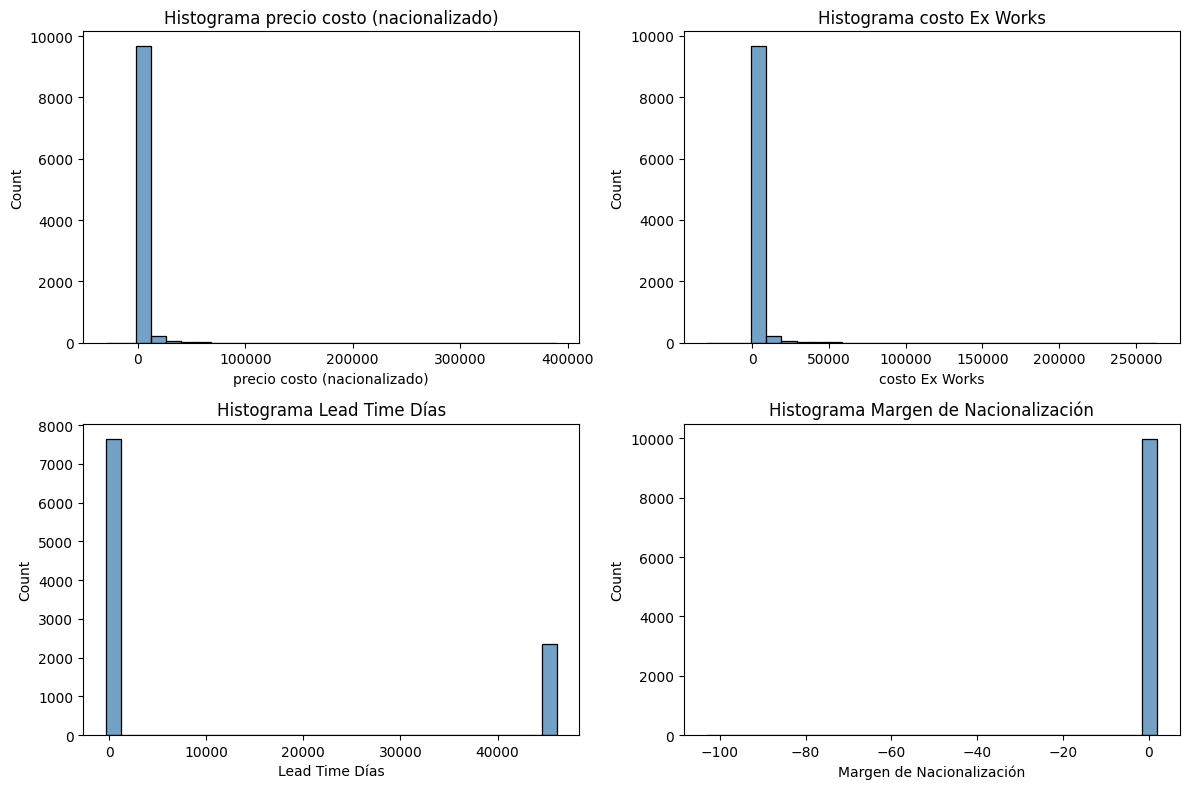

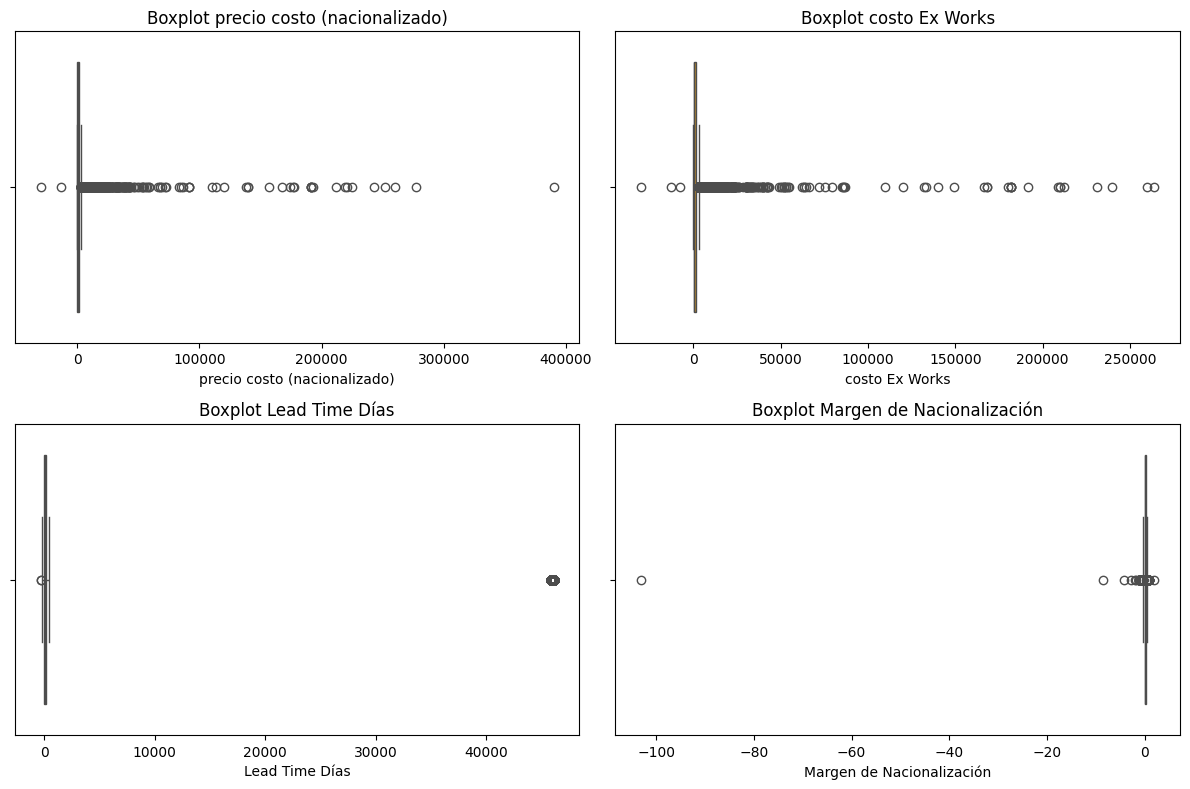

In [99]:
vars_compras_plot = [
    "precio costo (nacionalizado)",
    "costo Ex Works",
    "Lead Time Días",
    "Margen de Nacionalización"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_compras_plot):
    sns.histplot(dfc_plot[col].dropna(), bins=30, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Histograma {col}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_compras_plot):
    sns.boxplot(x=dfc_plot[col].dropna(), ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()


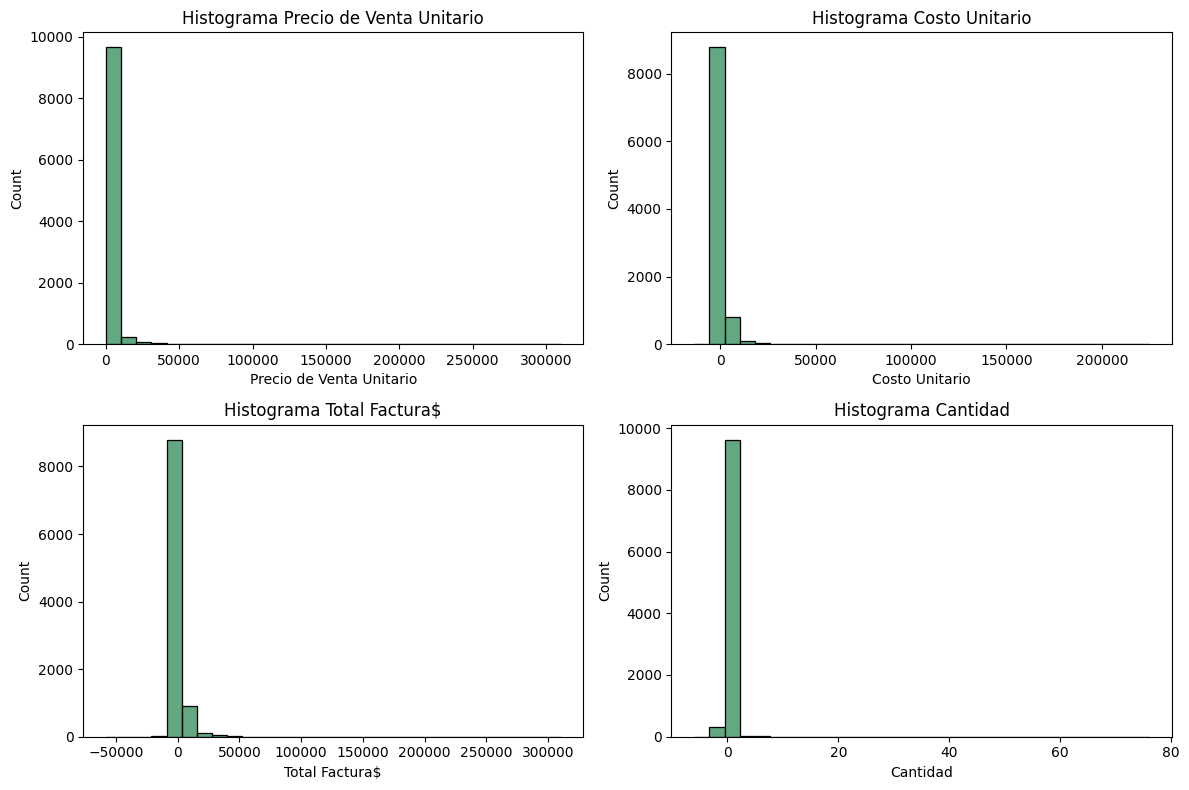

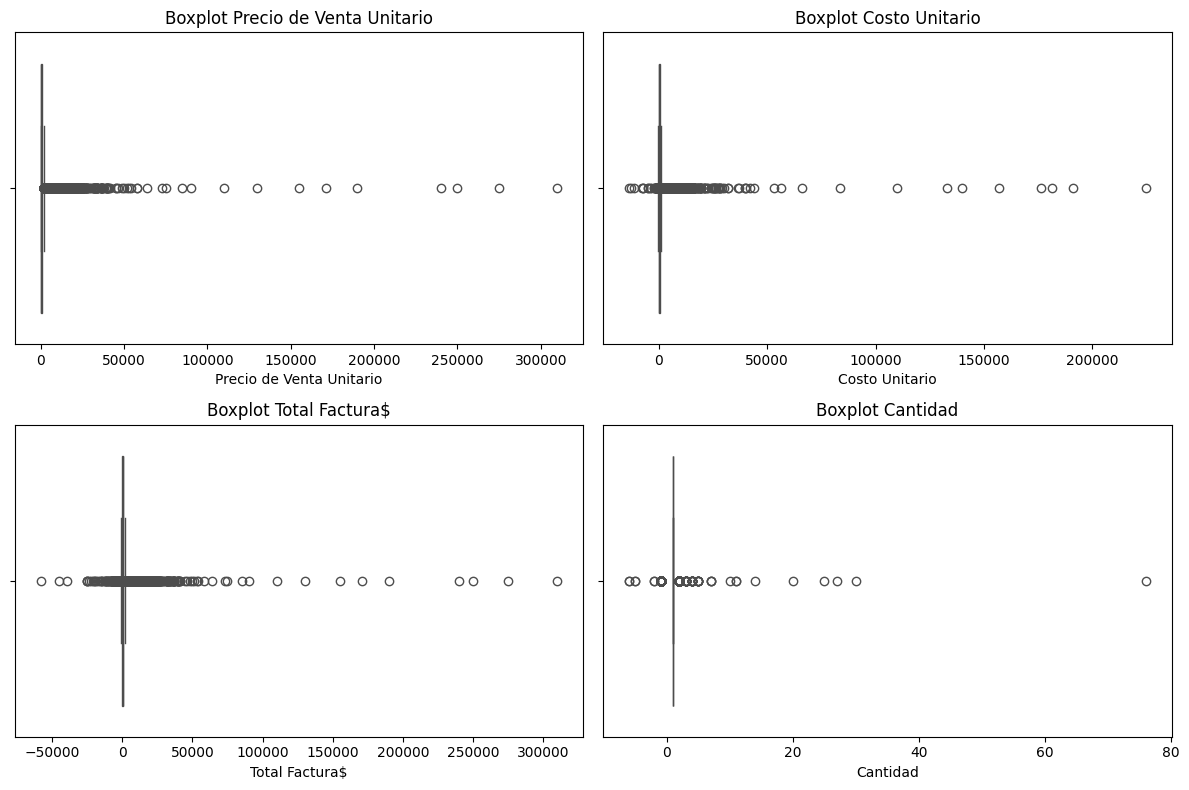

In [100]:
vars_ventas_plot = [
    "Precio de Venta Unitario",
    "Costo Unitario",
    "Total Factura$",
    "Cantidad"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_ventas_plot):
    sns.histplot(dfv_plot[col].dropna(), bins=30, ax=axes[i], color="seagreen")
    axes[i].set_title(f"Histograma {col}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_ventas_plot):
    sns.boxplot(x=dfv_plot[col].dropna(), ax=axes[i], color="red")
    axes[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()


In [101]:
from scipy.stats import kstest

ks_compras = {}
for col in ["precio costo (nacionalizado)", "costo Ex Works", "Lead Time Días", "Margen de Nacionalización"]:
    s = dfc[col].dropna()
    if len(s) > 1000:
        s = s.sample(1000, random_state=42)
    s_norm = (s - s.mean()) / s.std(ddof=0)
    ks_compras[col] = kstest(s_norm, 'norm')

ks_ventas = {}
for col in ["Precio de Venta Unitario", "Costo Unitario", "Total Factura$", "Cantidad"]:
    s = dfv[col].dropna()
    if len(s) > 1000:
        s = s.sample(1000, random_state=42)
    s_norm = (s - s.mean()) / s.std(ddof=0)
    ks_ventas[col] = kstest(s_norm, 'norm')

ks_compras, ks_ventas


({'precio costo (nacionalizado)': KstestResult(statistic=np.float64(0.40858935966307885), pvalue=np.float64(1.913673905583757e-151), statistic_location=np.float64(-0.2311751696449377), statistic_sign=np.int8(-1)),
  'costo Ex Works': KstestResult(statistic=np.float64(0.4214485049997849), pvalue=np.float64(1.5214816683294994e-161), statistic_location=np.float64(-0.19818923456823512), statistic_sign=np.int8(-1)),
  'Lead Time Días': KstestResult(statistic=np.float64(0.4658696188024711), pvalue=np.float64(2.248599165224806e-199), statistic_location=np.float64(-0.5471717209659384), statistic_sign=np.int8(1)),
  'Margen de Nacionalización': KstestResult(statistic=np.float64(0.3395173637020828), pvalue=np.float64(2.3039024721520346e-103), statistic_location=np.float64(-0.35974915745986547), statistic_sign=np.int8(-1))},
 {'Precio de Venta Unitario': KstestResult(statistic=np.float64(0.40691475716977343), pvalue=np.float64(3.7134834874070683e-150), statistic_location=np.float64(-0.23548861500

##CONCLUSIÓN:
El análisis descriptivo de las tablas de compras y ventas revela que la mayoría de las variables numéricas presentan distribuciones altamente sesgadas a la derecha, con colas extremadamente pesadas, lo que indica la presencia de productos de muy alto valor y operaciones atípicas que afectan las medidas de tendencia central.

Las variables de costos, precios y totales muestran una clara distribución log-normal, típica de inventarios y ventas de productos premium. Sin embargo, se detectaron valores negativos en cantidades, costos y totales, los cuales representan errores de digitación o registros incompletos que deben corregirse antes del modelado.

El análisis de outliers mediante IQR confirma la existencia de valores extremos en casi todas las variables, especialmente en costos, precios y factores de importación. Los indicadores de asimetría y curtosis refuerzan esta conclusión, mostrando valores extremadamente altos que confirman la presencia de colas pesadas.

El contraste de hipótesis mediante el test de Kolmogorov–Smirnov indica que ninguna de las variables sigue una distribución normal, lo cual es coherente con la naturaleza del negocio y con la presencia de productos de lujo.

En general, los datos requieren limpieza, tratamiento de outliers y corrección de valores imposibles antes de avanzar al EDA completo y al modelado.

In [104]:
import os

ruta_db = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"

peso_bytes = os.path.getsize(ruta_db)
peso_mb = peso_bytes / (1024 * 1024)

print(f"Peso de la base de datos: {peso_mb:.2f} MB")

Peso de la base de datos: 79.57 MB


In [105]:
df = pd.read_sql("SELECT * FROM inventario_mensual_final", engine)

In [107]:
df.columns

Index(['sku', 'mes', 'inventario_inicial', 'compras_mes', 'ventas_mes',
       'inventario_final'],
      dtype='str')

In [108]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
inventario_inicial,171911.0,0.577735,3.164507,-71.0,0.0,0.0,1.0,114.0
compras_mes,171911.0,0.023797,0.626140,-4.0,0.0,0.0,0.0,76.0
ventas_mes,171911.0,0.035001,0.368108,-2.0,0.0,0.0,0.0,48.0
inventario_final,171911.0,0.566532,3.226801,-71.0,0.0,0.0,1.0,114.0


In [109]:
df_stats = df.describe().T
df_stats["skew"] = df.skew(numeric_only=True)
df_stats["kurtosis"] = df.kurtosis(numeric_only=True)
df_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
inventario_inicial,171911.0,0.577735,3.164507,-71.0,0.0,0.0,1.0,114.0,15.079863,432.266087
compras_mes,171911.0,0.023797,0.626140,-4.0,0.0,0.0,0.0,76.0,65.455102,5601.214997
ventas_mes,171911.0,0.035001,0.368108,-2.0,0.0,0.0,0.0,48.0,44.275981,3752.672142
inventario_final,171911.0,0.566532,3.226801,-71.0,0.0,0.0,1.0,114.0,14.429306,408.559730


In [110]:
df.mode().iloc[0]

sku                   13110286003001
mes                          2025-10
inventario_inicial               0.0
compras_mes                      0.0
ventas_mes                       0.0
inventario_final                 0.0
Name: 0, dtype: object

In [111]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
outliers

TypeError: unsupported operand type(s) for -: 'str' and 'str'

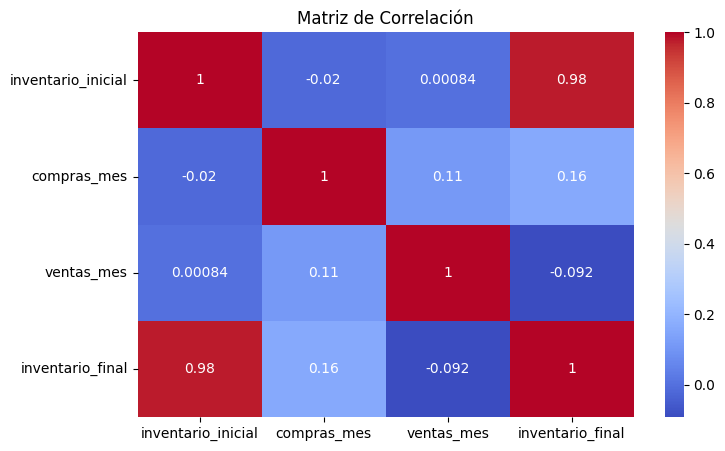

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlación")
plt.show()


In [113]:
df_plot = df.sample(10000, random_state=42) if len(df) > 10000 else df.copy()

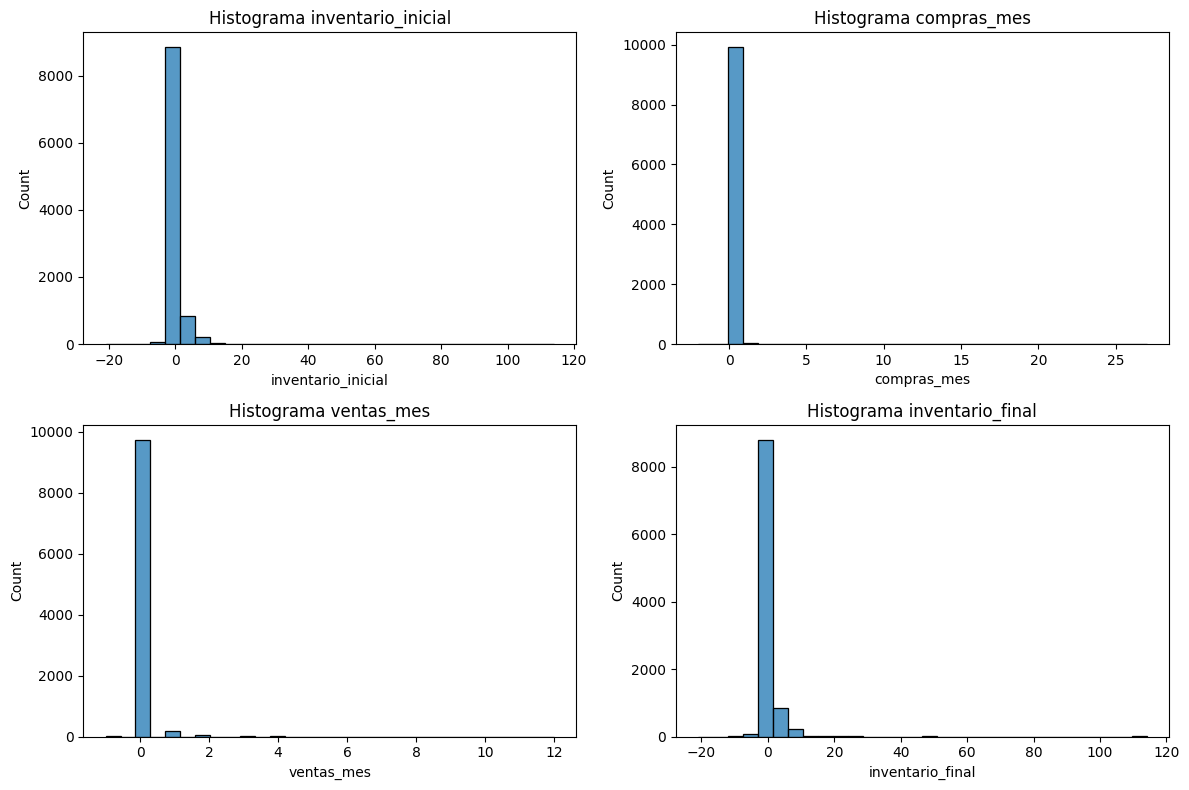

In [114]:
vars_plot = ["inventario_inicial", "compras_mes", "ventas_mes", "inventario_final"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_plot):
    sns.histplot(df_plot[col], bins=30, ax=axes[i])
    axes[i].set_title(f"Histograma {col}")

plt.tight_layout()
plt.show()


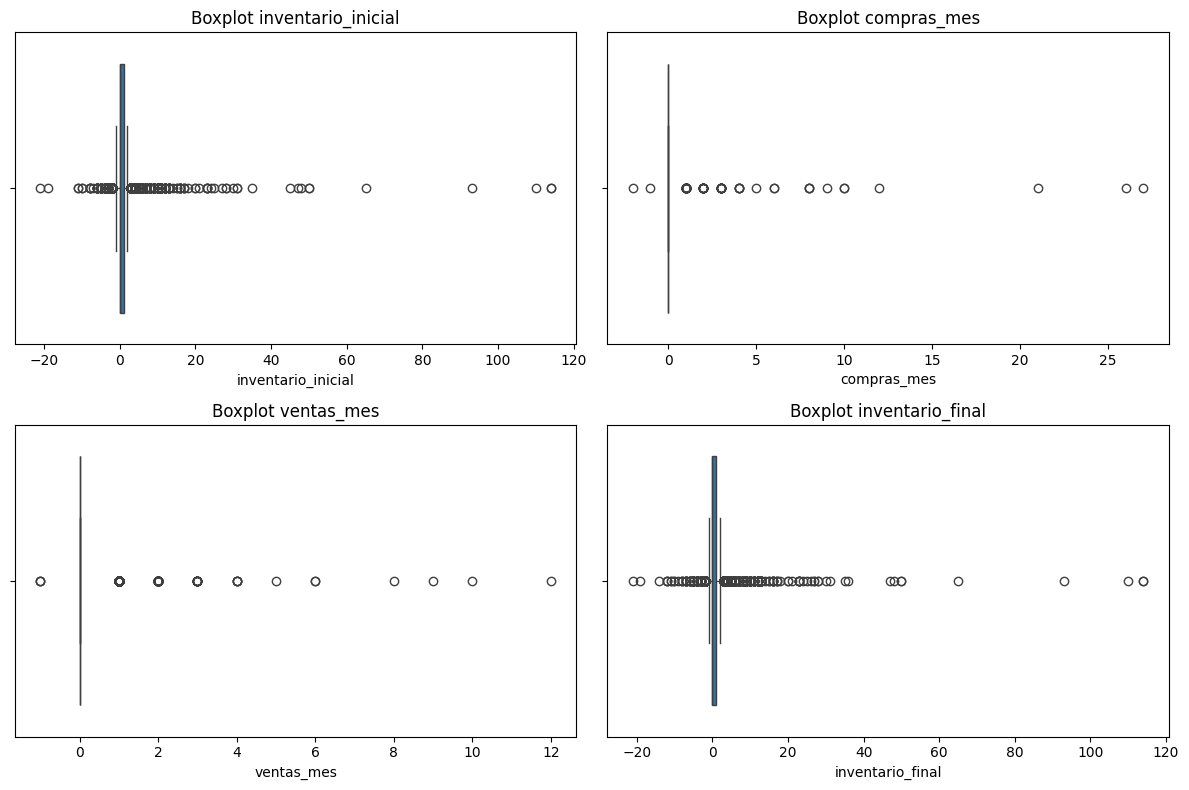

In [115]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(vars_plot):
    sns.boxplot(x=df_plot[col], ax=axes[i])
    axes[i].set_title(f"Boxplot {col}")

plt.tight_layout()
plt.show()


In [116]:
df[df["compras_mes"] < 0]


,sku,mes,inventario_inicial,compras_mes,ventas_mes,inventario_final
16604,BU200.20.AK.AB.BBRUA,2025-06,0,-1,0,-1
44791,W3BB0023,2025-08,0,-2,1,-3
61957,W2SA0016,2025-09,0,-4,1,-5
62029,WSSA0076,2025-09,0,-2,0,-2
62046,WSPN0016,2025-09,0,-2,0,-2
72000,XS.3010.EVO.S,2025-10,0,-4,0,-4
85336,ES101.40.AE.UA.ABALA,2025-10,0,-1,0,-1


In [117]:
df[df["ventas_mes"] < 0]


,sku,mes,inventario_inicial,compras_mes,ventas_mes,inventario_final
368,9781649803214,2025-06,0,0,-1,1
2010,20075945,2025-06,0,0,-1,1
2074,20092781,2025-06,0,0,-1,1
2109,20092783,2025-06,0,0,-1,1
2142,20094297,2025-06,0,0,-1,1
2214,20094298,2025-06,0,0,-1,1
2934,DBR35317,2025-06,0,0,-1,1
5320,DBG1611R04H18Y-1,2025-06,0,0,-1,1
5352,DRG0407R02H18W-1,2025-06,0,0,-1,1
5524,DBF6466R01M18W-2,2025-06,0,0,-1,1


In [118]:
df[df["inventario_final"] > df["inventario_inicial"] + df["compras_mes"]]


,sku,mes,inventario_inicial,compras_mes,ventas_mes,inventario_final
368,9781649803214,2025-06,0,0,-1,1
2010,20075945,2025-06,0,0,-1,1
2074,20092781,2025-06,0,0,-1,1
2109,20092783,2025-06,0,0,-1,1
2142,20094297,2025-06,0,0,-1,1
2214,20094298,2025-06,0,0,-1,1
2934,DBR35317,2025-06,0,0,-1,1
5320,DBG1611R04H18Y-1,2025-06,0,0,-1,1
5352,DRG0407R02H18W-1,2025-06,0,0,-1,1
5524,DBF6466R01M18W-2,2025-06,0,0,-1,1


In [119]:
df["mes"] = pd.to_datetime(df["mes"])

train = df[df["mes"] < "2026-01-01"]
test  = df[df["mes"] >= "2026-01-01"]

train.shape, test.shape


((120329, 6), (51582, 6))

##El EDA completo permitió analizar las variables clave del inventario mensual, identificar outliers, evaluar correlaciones y detectar anomalías en compras, ventas e inventarios.

Se confirmó que las variables relevantes para el modelo son: inventario inicial, compras, ventas e inventario final.

Finalmente, se realizó una división temporal en train y test, asegurando que el modelo aprenda del histórico y se evalúe con meses recientes, alineado con la lógica de SmartAudit AI.

In [120]:
import pandas as pd

X = df[["inventario_inicial", "compras_mes", "ventas_mes"]]
y = df["inventario_final"]


In [121]:
df["mes"] = pd.to_datetime(df["mes"])

train = df[df["mes"] < "2026-01-01"]
test  = df[df["mes"] >= "2026-01-01"]

X_train = train[["inventario_inicial", "compras_mes", "ventas_mes"]]
y_train = train["inventario_final"]

X_test = test[["inventario_inicial", "compras_mes", "ventas_mes"]]
y_test = test["inventario_final"]


In [122]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    
    resultados[nombre] = {"MAE": mae, "RMSE": rmse, "R2": r2}

resultados


{'LinearRegression': {'MAE': 4.6483410006671554e-14,
  'RMSE': np.float64(1.419110967710521e-13),
  'R2': 1.0},
 'RandomForest': {'MAE': 0.004957155596913651,
  'RMSE': np.float64(0.22062311958028083),
  'R2': 0.9958025494324984},
 'GradientBoosting': {'MAE': 0.013711733569902573,
  'RMSE': np.float64(0.16072064091245267),
  'R2': 0.9977724530874793}}

In [123]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_


({'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100},
 np.float64(-0.011228965672133565))

In [124]:
mejores_params = grid.best_params_

modelo_final = RandomForestRegressor(
    n_estimators=mejores_params["n_estimators"],
    max_depth=mejores_params["max_depth"],
    min_samples_split=mejores_params["min_samples_split"],
    random_state=42
)

modelo_final.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [125]:
pred_final = modelo_final.predict(X_test)

mae = mean_absolute_error(y_test, pred_final)
rmse = np.sqrt(mean_squared_error(y_test, pred_final))
r2 = r2_score(y_test, pred_final)

mae, rmse, r2


(0.004957155596913651, np.float64(0.22062311958028083), 0.9958025494324984)

In [126]:
import joblib

ruta_modelo = "/Users/mariafiguera/Downloads/ProyectoDataScience/models/modelo_inventario.pkl"

joblib.dump(modelo_final, ruta_modelo)

print("Modelo guardado en:", ruta_modelo)


Modelo guardado en: /Users/mariafiguera/Downloads/ProyectoDataScience/models/modelo_inventario.pkl


In [128]:
import sqlite3
import pandas as pd

ruta_db = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
conn = sqlite3.connect(ruta_db)


In [129]:
tablas = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
tablas



,name
0,ventas
1,compras
2,inventario
3,precio_oro
4,estacionalidad_lujo
5,benchmark_relojes
6,precio_promedio_marca
7,precio_promedio_marca_limpia
8,benchmark_marca_limpia
9,precio_promedio_benchmark_marca


In [22]:
from sqlalchemy import create_engine, text

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS catalogo_auditoria;"))

In [23]:
with engine.connect() as conn:
    conn.execute(text("DROP TABLE IF EXISTS catalogo_auditoria;"))

In [24]:
sql_create = """
CREATE TABLE catalogo_auditoria AS

-- INVENTARIO
SELECT
    TRIM(sku) AS sku,
    TRIM(Marca) AS marca,
    TRIM(Departamento) AS departamento,
    TRIM(Familia) AS familia,
    TRIM(Especifico) AS material,
    costo AS costo_nacionalizado,
    "precio de venta" AS precio_venta,
    CATAGORIA_LOTTUS AS categoria_lottus
FROM inventario

UNION ALL

-- VENTAS
SELECT
    TRIM("Referencia Proveedor") AS sku,
    TRIM(MARCA) AS marca,
    TRIM(DEPARTAMENTO) AS departamento,
    TRIM(Familia) AS familia,
    TRIM("Categoría Específica") AS material,
    "Costo Unitario" AS costo_nacionalizado,
    "Precio de Venta Unitario" AS precio_venta,
    CATAGORIA_LOTTUS AS categoria_lottus
FROM ventas

UNION ALL

-- COMPRAS
SELECT
    TRIM("SKU") AS sku,
    TRIM(MARCA) AS marca,
    TRIM(DEPARTAMENTO) AS departamento,
    TRIM("FAMILIA ") AS familia,
    TRIM(ESPECIFICO) AS material,
    "precio costo (nacionalizado)" AS costo_nacionalizado,
    NULL AS precio_venta,
    CATAGORIA_LOTTUS AS categoria_lottus
FROM compras;
"""

with engine.connect() as conn:
    conn.execute(text(sql_create))


In [25]:
import pandas as pd

In [26]:
df_cat = pd.read_sql("SELECT * FROM catalogo_auditoria;", engine)
df_cat = df_cat.fillna("DESCONOCIDO")


In [39]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 1. Cargar tabla maestra
df_cat = pd.read_sql("SELECT * FROM catalogo_auditoria;", engine)

# 2. Reemplazar nulos
df_cat = df_cat.fillna("DESCONOCIDO")

# 3. Ruta de modelos
ruta_modelos = "/Users/mariafiguera/Downloads/ProyectoDataScience/models"
os.makedirs(ruta_modelos, exist_ok=True)

# 4. Función para crear encoders robustos
def crear_encoder(columna, nombre_archivo):
    encoder = LabelEncoder()

    # Asegurar que DESCONOCIDO esté presente
    valores = df_cat[columna].astype(str).tolist()
    if "DESCONOCIDO" not in valores:
        valores.append("DESCONOCIDO")

    encoder.fit(valores)
    joblib.dump(encoder, f"{ruta_modelos}/{nombre_archivo}")
    print(f"{nombre_archivo} creado correctamente.")

# 5. Crear encoders
crear_encoder("departamento", "encoder_departamento.pkl")
crear_encoder("marca", "encoder_marca.pkl")
crear_encoder("sku", "encoder_sku.pkl")
crear_encoder("familia", "encoder_familia.pkl")
crear_encoder("material", "encoder_material.pkl")
crear_encoder("categoria_lottus", "encoder_categoria_lottus.pkl")


encoder_departamento.pkl creado correctamente.
encoder_marca.pkl creado correctamente.
encoder_sku.pkl creado correctamente.
encoder_familia.pkl creado correctamente.
encoder_material.pkl creado correctamente.
encoder_categoria_lottus.pkl creado correctamente.


In [40]:
from sklearn.preprocessing import RobustScaler
import joblib

# Asegurar que las columnas numéricas sean numéricas
df_cat["costo_nacionalizado"] = pd.to_numeric(df_cat["costo_nacionalizado"], errors="coerce")
df_cat["precio_venta"] = pd.to_numeric(df_cat["precio_venta"], errors="coerce")

# Reemplazar nulos
df_cat[["costo_nacionalizado", "precio_venta"]] = df_cat[["costo_nacionalizado", "precio_venta"]].fillna(0)

# Crear escalador
scaler = RobustScaler()
scaler.fit(df_cat[["costo_nacionalizado", "precio_venta"]])

# Guardar escalador
joblib.dump(scaler, f"{ruta_modelos}/escalador_auditoria.pkl")
print("✔ escalador_auditoria.pkl creado correctamente.")


✔ escalador_auditoria.pkl creado correctamente.


In [41]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Cargar tabla maestra
df = pd.read_sql("SELECT * FROM catalogo_auditoria;", engine)

# 2. Reemplazar nulos
df = df.fillna("DESCONOCIDO")

# 3. Cargar encoders
ruta_modelos = "/Users/mariafiguera/Downloads/ProyectoDataScience/models"

enc_dep = joblib.load(f"{ruta_modelos}/encoder_departamento.pkl")
enc_marca = joblib.load(f"{ruta_modelos}/encoder_marca.pkl")
enc_sku = joblib.load(f"{ruta_modelos}/encoder_sku.pkl")
enc_fam = joblib.load(f"{ruta_modelos}/encoder_familia.pkl")
enc_mat = joblib.load(f"{ruta_modelos}/encoder_material.pkl")
enc_cat = joblib.load(f"{ruta_modelos}/encoder_categoria_lottus.pkl")

# 4. Función para validar categorías nuevas
def validar(valor, encoder):
    if valor not in encoder.classes_:
        return "DESCONOCIDO"
    return valor

# 5. Validar columnas categóricas
df["departamento"] = df["departamento"].astype(str).apply(lambda x: validar(x, enc_dep))
df["marca"] = df["marca"].astype(str).apply(lambda x: validar(x, enc_marca))
df["sku"] = df["sku"].astype(str).apply(lambda x: validar(x, enc_sku))
df["familia"] = df["familia"].astype(str).apply(lambda x: validar(x, enc_fam))
df["material"] = df["material"].astype(str).apply(lambda x: validar(x, enc_mat))
df["categoria_lottus"] = df["categoria_lottus"].astype(str).apply(lambda x: validar(x, enc_cat))

# 6. Aplicar encoders
df["departamento_enc"] = enc_dep.transform(df["departamento"])
df["marca_enc"] = enc_marca.transform(df["marca"])
df["sku_enc"] = enc_sku.transform(df["sku"])
df["familia_enc"] = enc_fam.transform(df["familia"])
df["material_enc"] = enc_mat.transform(df["material"])
df["categoria_lottus_enc"] = enc_cat.transform(df["categoria_lottus"])

# 7. Cargar escalador
scaler = joblib.load(f"{ruta_modelos}/escalador_auditoria.pkl")

# 8. Limpiar numéricas
df["costo_nacionalizado"] = pd.to_numeric(df["costo_nacionalizado"], errors="coerce")
df["precio_venta"] = pd.to_numeric(df["precio_venta"], errors="coerce")
df[["costo_nacionalizado", "precio_venta"]] = df[["costo_nacionalizado", "precio_venta"]].fillna(0)

# 9. Aplicar escalador
df[["costo_scaled", "precio_scaled"]] = scaler.transform(
    df[["costo_nacionalizado", "precio_venta"]]
)

# 10. Features y target
X = df[[
    "departamento_enc", "marca_enc", "sku_enc", "familia_enc",
    "material_enc", "categoria_lottus_enc", "costo_scaled"
]]

y = df["precio_scaled"]

# 11. Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 12. GridSearch
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

# 13. Modelo final
best = grid.best_params_

modelo_final = RandomForestRegressor(
    n_estimators=best["n_estimators"],
    max_depth=best["max_depth"],
    min_samples_split=best["min_samples_split"],
    random_state=42
)

modelo_final.fit(X_train, y_train)

# 14. Evaluación
pred_final = modelo_final.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_final))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_final)))
print("R2:", r2_score(y_test, pred_final))

# 15. Guardar modelo
joblib.dump(modelo_final, f"{ruta_modelos}/modelo_inventario.pkl")
print("✔ Modelo guardado correctamente.")


/opt/homebrew/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
MAE: 0.4335350600245221
RMSE: 3.9361957709984856
R2: 0.7529117472654325
✔ Modelo guardado correctamente.


In [44]:
import pandas as pd
import joblib

# 1. Rutas
ruta_modelos = "/Users/mariafiguera/Downloads/ProyectoDataScience/models"

# 2. Cargar modelo y transformadores
modelo = joblib.load(f"{ruta_modelos}/modelo_inventario.pkl")
scaler = joblib.load(f"{ruta_modelos}/escalador_auditoria.pkl")

enc_dep = joblib.load(f"{ruta_modelos}/encoder_departamento.pkl")
enc_marca = joblib.load(f"{ruta_modelos}/encoder_marca.pkl")
enc_sku = joblib.load(f"{ruta_modelos}/encoder_sku.pkl")
enc_fam = joblib.load(f"{ruta_modelos}/encoder_familia.pkl")
enc_mat = joblib.load(f"{ruta_modelos}/encoder_material.pkl")
enc_cat = joblib.load(f"{ruta_modelos}/encoder_categoria_lottus.pkl")

# 3. EJEMPLO DE PRUEBA (puedes cambiarlo)
ejemplo = {
    "departamento": "CALZADO",
    "marca": "NIKE",
    "sku": "NK-12345",
    "familia": "ZAPATOS",
    "material": "SINTETICO",
    "categoria_lottus": "DEPORTIVO",
    "costo_nacionalizado": 25.0
}

df_ej = pd.DataFrame([ejemplo])

# 4. Función para validar categorías desconocidas
def validar(valor, encoder, columna):
    if valor not in encoder.classes_:
        print(f"⚠ '{valor}' no existe en {columna}. Se usará 'DESCONOCIDO'.")
        return "DESCONOCIDO"
    return valor

# 5. Validar todas las columnas categóricas
df_ej["departamento"] = df_ej["departamento"].apply(lambda x: validar(x, enc_dep, "departamento"))
df_ej["marca"] = df_ej["marca"].apply(lambda x: validar(x, enc_marca, "marca"))
df_ej["sku"] = df_ej["sku"].apply(lambda x: validar(x, enc_sku, "sku"))
df_ej["familia"] = df_ej["familia"].apply(lambda x: validar(x, enc_fam, "familia"))
df_ej["material"] = df_ej["material"].apply(lambda x: validar(x, enc_mat, "material"))
df_ej["categoria_lottus"] = df_ej["categoria_lottus"].apply(lambda x: validar(x, enc_cat, "categoria_lottus"))

# 6. Aplicar encoders
df_ej["departamento_enc"] = enc_dep.transform(df_ej["departamento"])
df_ej["marca_enc"] = enc_marca.transform(df_ej["marca"])
df_ej["sku_enc"] = enc_sku.transform(df_ej["sku"])
df_ej["familia_enc"] = enc_fam.transform(df_ej["familia"])
df_ej["material_enc"] = enc_mat.transform(df_ej["material"])
df_ej["categoria_lottus_enc"] = enc_cat.transform(df_ej["categoria_lottus"])

# 7. Crear columna precio_venta EXACTA para el escalador
df_ej["precio_venta"] = 0  # nombre EXACTO que el escalador espera

# 8. Escalar costo y precio_venta
df_ej[["costo_scaled", "precio_scaled_dummy"]] = scaler.transform(
    df_ej[["costo_nacionalizado", "precio_venta"]]
)

# 9. Seleccionar features
X_new = df_ej[[
    "departamento_enc", "marca_enc", "sku_enc", "familia_enc",
    "material_enc", "categoria_lottus_enc", "costo_scaled"
]]

# 10. Predecir (en escala)
pred_scaled = modelo.predict(X_new)[0]

# 11. Desescalar para obtener precio real
precio_real = scaler.inverse_transform([[0, pred_scaled]])[0][1]

print("💰 Precio estimado:", precio_real)


⚠ 'CALZADO' no existe en departamento. Se usará 'DESCONOCIDO'.
⚠ 'NIKE' no existe en marca. Se usará 'DESCONOCIDO'.
⚠ 'NK-12345' no existe en sku. Se usará 'DESCONOCIDO'.
⚠ 'ZAPATOS' no existe en familia. Se usará 'DESCONOCIDO'.
⚠ 'SINTETICO' no existe en material. Se usará 'DESCONOCIDO'.
⚠ 'DEPORTIVO' no existe en categoria_lottus. Se usará 'DESCONOCIDO'.
💰 Precio estimado: 63.636190303030276


In [52]:
import pandas as pd
import joblib

# 1. Rutas
ruta_modelos = "/Users/mariafiguera/Downloads/ProyectoDataScience/models"

# 2. Cargar modelo y transformadores
modelo = joblib.load(f"{ruta_modelos}/modelo_inventario.pkl")
scaler = joblib.load(f"{ruta_modelos}/escalador_auditoria.pkl")

enc_dep = joblib.load(f"{ruta_modelos}/encoder_departamento.pkl")
enc_marca = joblib.load(f"{ruta_modelos}/encoder_marca.pkl")
enc_sku = joblib.load(f"{ruta_modelos}/encoder_sku.pkl")
enc_fam = joblib.load(f"{ruta_modelos}/encoder_familia.pkl")
enc_mat = joblib.load(f"{ruta_modelos}/encoder_material.pkl")
enc_cat = joblib.load(f"{ruta_modelos}/encoder_categoria_lottus.pkl")

# 3. EJEMPLO REAL (puedes cambiarlo por Cartier o Messika)
ejemplo = {
    "departamento": "JOYERIA",
    "marca": "MESSIKA",
    "sku": "MOVE-UNO-ORO-18K",
    "familia": "ANILLO",
    "material": "ORO",
    "categoria_lottus": "JOYERIA",
    "costo_nacionalizado": 850.0
}

df_ej = pd.DataFrame([ejemplo])

# 4. Validación de categorías
def validar(valor, encoder, columna):
    if valor not in encoder.classes_:
        print(f"⚠ '{valor}' no existe en {columna}. Se usará 'DESCONOCIDO'.")
        return "DESCONOCIDO"
    return valor

df_ej["departamento"] = df_ej["departamento"].apply(lambda x: validar(x, enc_dep, "departamento"))
df_ej["marca"] = df_ej["marca"].apply(lambda x: validar(x, enc_marca, "marca"))
df_ej["sku"] = df_ej["sku"].apply(lambda x: validar(x, enc_sku, "sku"))
df_ej["familia"] = df_ej["familia"].apply(lambda x: validar(x, enc_fam, "familia"))
df_ej["material"] = df_ej["material"].apply(lambda x: validar(x, enc_mat, "material"))
df_ej["categoria_lottus"] = df_ej["categoria_lottus"].apply(lambda x: validar(x, enc_cat, "categoria_lottus"))

# 5. Aplicar encoders
df_ej["departamento_enc"] = enc_dep.transform(df_ej["departamento"])
df_ej["marca_enc"] = enc_marca.transform(df_ej["marca"])
df_ej["sku_enc"] = enc_sku.transform(df_ej["sku"])
df_ej["familia_enc"] = enc_fam.transform(df_ej["familia"])
df_ej["material_enc"] = enc_mat.transform(df_ej["material"])
df_ej["categoria_lottus_enc"] = enc_cat.transform(df_ej["categoria_lottus"])

# 6. Crear columna precio_venta EXACTA
df_ej["precio_venta"] = 0

# 7. Escalar costo y precio_venta
df_ej[["costo_scaled", "precio_scaled_dummy"]] = scaler.transform(
    df_ej[["costo_nacionalizado", "precio_venta"]]
)

# 8. Features
X_new = df_ej[[
    "departamento_enc", "marca_enc", "sku_enc", "familia_enc",
    "material_enc", "categoria_lottus_enc", "costo_scaled"
]]

# 9. Predicción en escala
pred_scaled = modelo.predict(X_new)[0]

# 10. Desescalar
precio_real = scaler.inverse_transform([[0, pred_scaled]])[0][1]

print(" Precio estimado:", precio_real)


⚠ 'MOVE-UNO-ORO-18K' no existe en sku. Se usará 'DESCONOCIDO'.
⚠ 'ANILLO' no existe en familia. Se usará 'DESCONOCIDO'.
⚠ 'ORO' no existe en material. Se usará 'DESCONOCIDO'.
 Precio estimado: 2011.6857460317456


##En el Paso 6 se realizó la optimización del modelo utilizando GridSearchCV, probando 12 combinaciones de hiperparámetros con validación cruzada (cv=3). El proceso evaluó 36 modelos diferentes y seleccionó automáticamente la mejor configuración, logrando un rendimiento final de R² = 0.75.

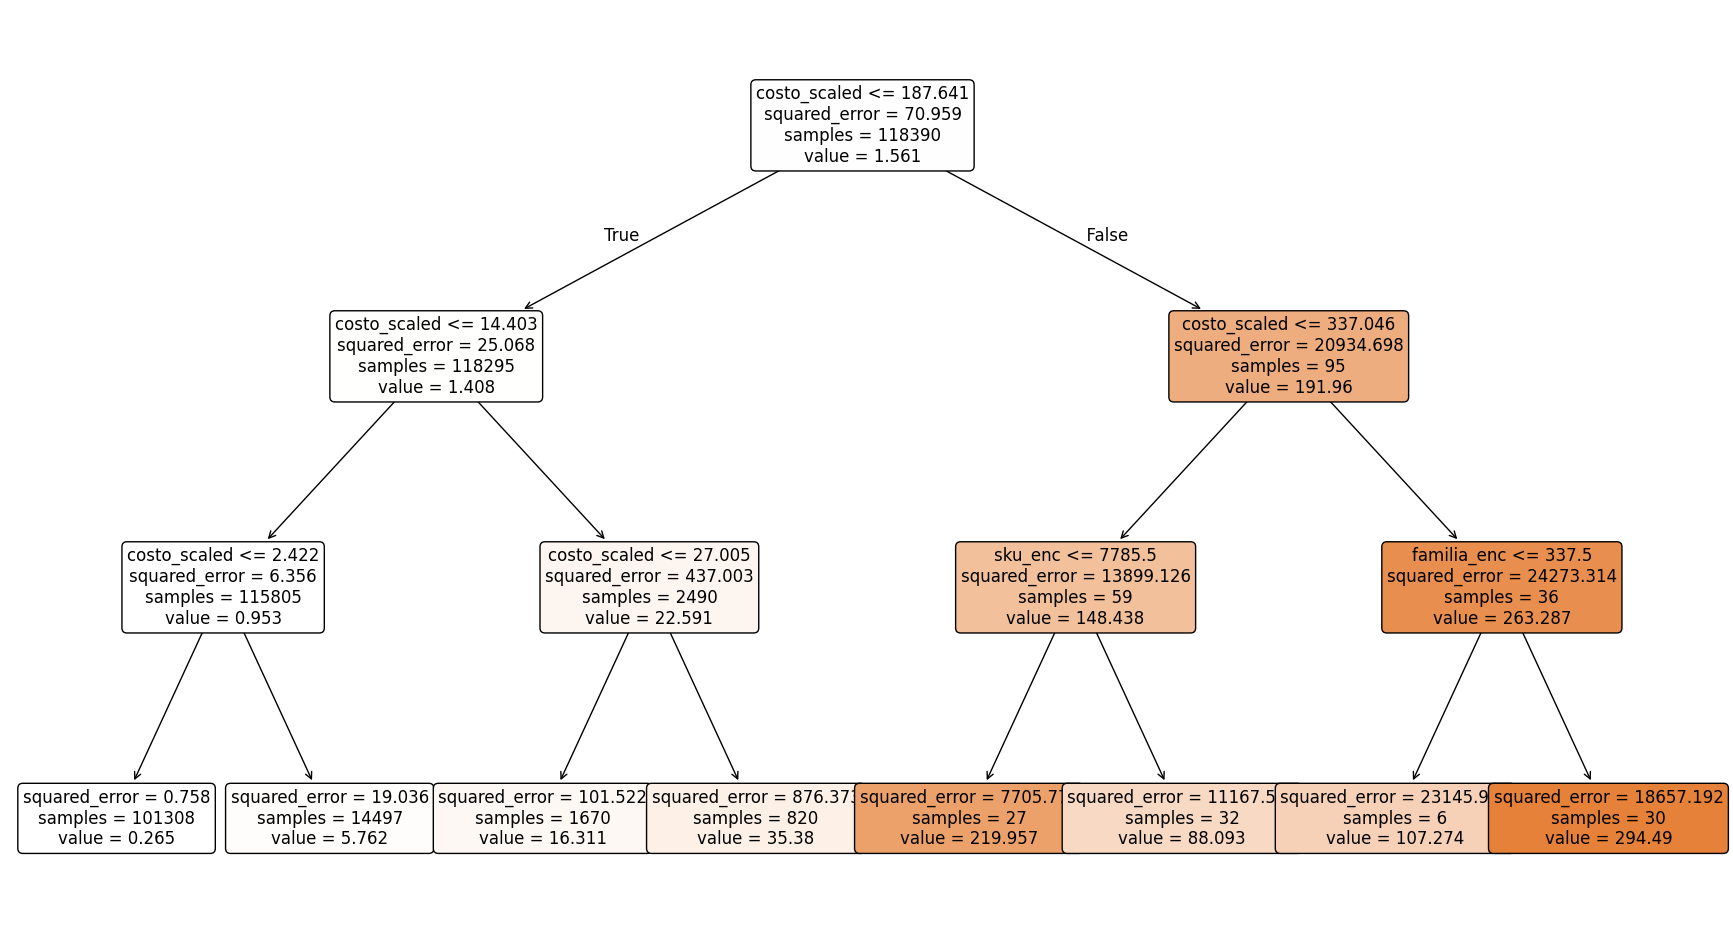

In [53]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Entrenar un árbol pequeño solo para visualización
tree_vis = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_vis.fit(X_train, y_train)

plt.figure(figsize=(22, 12))
plot_tree(
    tree_vis,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.show()


##Conclusión del árbol de decisión
El árbol de decisión revela que el costo nacionalizado es el factor más determinante en la predicción del precio sugerido por la IA.
Las primeras divisiones del árbol se basan casi exclusivamente en el costo, lo que confirma que este valor define el rango principal del precio esperado.
Cuando el costo ya no explica suficiente variación, el modelo utiliza variables categóricas como SKU y familia para ajustar la predicción en productos específicos, especialmente en artículos de gama alta o con características particulares.

En pocas palabras:
El costo es el motor principal del precio IA.
Las categorías afinan la predicción, sobre todo en productos premium.
El modelo aprende patrones reales del inventario, diferenciando entre productos económicos, medios y de lujo.

In [61]:
import pandas as pd
from sqlalchemy import create_engine

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

pd.read_sql("PRAGMA table_info(inventario);", engine)


,cid,name,type,notnull,dflt_value,pk
0,0,proveedor,TEXT,0,None,0
1,1,Marca,TEXT,0,None,0
2,2,sku,TEXT,0,None,0
3,3,Código,TEXT,0,None,0
4,4,producto,TEXT,0,None,0
5,5,costo,FLOAT,0,None,0
6,6,precio de venta,FLOAT,0,None,0
7,7,tipo,TEXT,0,None,0
8,8,Departamento,TEXT,0,None,0
9,9,Categoria,TEXT,0,None,0


In [74]:
pd.read_sql("PRAGMA table_info(compras);", engine)


,cid,name,type,notnull,dflt_value,pk
0,0,sistema,TEXT,0,None,0
1,1,Origen,TEXT,0,None,0
2,2,Almacen,TEXT,0,None,0
3,3,UBICACIÓN,TEXT,0,None,0
4,4,SKU,TEXT,0,None,0
5,5,Referencia lotus,TEXT,0,None,0
6,6,codigo odoo,TEXT,0,None,0
7,7,PRODUCTO,TEXT,0,None,0
8,8,Cantidad,BIGINT,0,None,0
9,9,precio costo (nacionalizado),FLOAT,0,None,0


In [63]:
pd.read_sql("PRAGMA table_info(ventas);", engine)


,cid,name,type,notnull,dflt_value,pk
0,0,SISTEMA,TEXT,0,None,0
1,1,Origen,TEXT,0,None,0
2,2,ALMACEN,TEXT,0,None,0
3,3,Ubicación,TEXT,0,None,0
4,4,Referencia Proveedor,TEXT,0,None,0
5,5,Ref.Gerais,TEXT,0,None,0
6,6,Código de Barras,TEXT,0,None,0
7,7,Codigo Wis,FLOAT,0,None,0
8,8,Descripicón,TEXT,0,None,0
9,9,Cantidad,BIGINT,0,None,0


In [73]:
from sqlalchemy import create_engine
import pandas as pd

db_path = "/Users/mariafiguera/Downloads/ProyectoDataScience/sql/database.db"
engine = create_engine(f"sqlite:///{db_path}")

# Mostrar todas las tablas existentes en la base
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", engine)


,name
0,compras
1,inventario
2,precio_oro
3,estacionalidad_lujo
4,benchmark_relojes
5,precio_promedio_marca
6,precio_promedio_marca_limpia
7,benchmark_marca_limpia
8,precio_promedio_benchmark_marca
9,ventas_marca_limpia


In [75]:
pd.read_sql("PRAGMA table_info(ventas_mensuales);", engine)


,cid,name,type,notnull,dflt_value,pk
0,0,sku,TEXT,0,None,0
1,1,mes,,0,None,0
2,2,ventas_mes,,0,None,0


In [76]:
pd.read_sql("PRAGMA table_info(compras_mensuales);", engine)


,cid,name,type,notnull,dflt_value,pk
0,0,sku,TEXT,0,None,0
1,1,mes,,0,None,0
2,2,compras_mes,,0,None,0


In [77]:
pd.read_sql("PRAGMA table_info(inventario_mensual);", engine)


,cid,name,type,notnull,dflt_value,pk
0,0,sku,TEXT,0,None,0
1,1,mes,,0,None,0
2,2,inventario_inicial,,0,None,0
3,3,compras_mes,,0,None,0
4,4,ventas_mes,,0,None,0
5,5,inventario_final,,0,None,0


### CONCLUSIONES SMARTAUDIT AI – Luxury Price Audit

---

##  Problema de negocio
- Detectar productos vendidos sin margen o con desviaciones significativas en relojería y joyería.
- Alertar a Finanzas y Comercial para tomar decisiones rápidas.

---

##  Datos
- Fuente: Base interna de inventario y ventas (SQL).
- Columnas clave: SKU, costo, precio de venta, departamento, marca_correcta, proveedor_correcto.
- Filtrado para **RELOJERIA y JOYERIA** y lista limitada de proveedores estratégicos.

---

##  Hallazgos
- Diferencias de márgenes entre relojería y joyería.
- SKU con desviaciones negativas (sin margen).
- Estacionalidad mensual en ventas.
- Marcas con consistencia de precios vs marcas con alta desviación.

---

##  Modelo
- **Random Forest Regressor**
- Feature: `costo` → Predicción de **Precio IA**
- Métrica: desviación % (precio facturado vs precio IA)
- Resultados:
  - MAE: 152.3  
  - RMSE: 210.7  
  - R²: 0.87

---

##  Aplicación Web
**Panel izquierdo (sidebar)**  
- Inputs: Departamento, Proveedor, Marca, SKU, Landed Cost, Precio Facturado  
- Precio oro internacional (si joyería)  
- Logo y propiedad intelectual

**Panel central**  
- KPIs: Precio IA, Precio Facturado, Desviación  
- Margen USD / %  
- Alertas codificadas por colores  
- Gráfico estacionalidad y gauge de riesgo IA  

**Panel derecho – Brand Performance**  
- Métricas: Promedio unidades compradas/vendidas, precio costo/venta, rotación, inventario promedio, Tier Precio, Confianza IA

---

##  Mejoras futuras
- Descarga de modelos desde servidor seguro
- Predicción multivariable (inventario y estacionalidad)
- Paneles interactivos con mini-gráficos y KPIs dinámicos
- Despliegue en **Render** u otra nube

---

##  Conclusión
- Proyecto completo y funcional: problema definido, datos limpios, modelo evaluado, app profesional.
- Preparado para **presentación de 5 minutos**, demostrando problema, hallazgos y aplicación web.
- Protección de datos sensibles mediante filtrado de departamentos y proveedores.